# 🎬 Project HOLLYWOOD
## Genome Clustering Pipeline — UMAP + HDBSCAN

---

**Goal**: Cluster 8,000 movies into content "rails" using the 269-feature genome
(247 continuous taxonomy + 22 binary genre), with optional ensemble distance and
audio feature integration.

**Pipeline**:
1. **Split Feature Views** (continuous vs binary)
2. **IDF + Variance Weighting** (continuous only)
3. **Ensemble Distance Matrix** *(optional test — `USE_ENSEMBLE_DISTANCE`)*
4. **UMAP Dimensionality Reduction** (precomputed or correlation)
5. **HDBSCAN Clustering** + parameter sweep with epsilon
6. **Recursive Sub-Clustering** (Spotify pattern)
7. **Soft Membership & Rail Assignment** (primary + secondary)
8. **Three-Tier Outlier Handling**

**Phase 2** *(optional — `ENABLE_PHASE2_AUDIO`)*:
- Trailer audio features as a third distance view (coverage-gated at 80%)

**Deliverables**: Named rails, descriptions, cohesion explanations, flaws, evaluation vs genre baseline

---

### 🏗️ Notebook Structure

**Part I: Setup & Data Loading**
- Pipeline Configuration (binary toggles)
- LLM Configuration (Ollama/vLLM)
- OMDB Data Integration + Phase 2 early gate
- Data Loading & Preprocessing

**Part II: Feature Engineering & Distance**
- Split Feature Views + IDF + Variance Weighting
- Ensemble Distance (optional)
- Phase 2 Audio Integration (optional)

**Part III: Dimensionality Reduction & Clustering**
- UMAP (precomputed or correlation)
- HDBSCAN + recursive sub-clustering
- Soft membership + three-tier outlier handling

**Part IV: Deliverables & Evaluation**
- 3D Visualisation + Cluster Naming
- Final Rails with Names & Descriptions
- Evaluation vs Genre Baseline

---
# Part I: Setup & Data Loading

## Step 1: LLM Configuration

We'll use **Ollama** for local LLM inference. Ollama is easy to set up and supports various models.

### Installation Instructions

```bash
# Install Ollama
curl -fsSL https://ollama.com/install.sh | sh

# Pull recommended model (choose one):
ollama pull llama3.2:3b     # Fastest, 3B parameters, good for tone extraction
ollama pull llama3.1:8b     # Balanced, 8B parameters (RECOMMENDED)
ollama pull mistral:7b      # Alternative, 7B parameters
```

### Why These Models?
- **llama3.1:8b** (Recommended): Best balance of quality and speed for feature extraction
- **llama3.2:3b**: Faster, good enough for tone tagging
- **mistral:7b**: Alternative with strong instruction following


### LLM Helper Functions

These functions wrap the Ollama API for our specific tasks:

In [717]:
import requests
import json
from typing import List, Dict
import time

# Configuration
OLLAMA_BASE_URL = 'http://localhost:11434'
OLLAMA_MODEL = 'llama3.2:3b'  # Change to your installed model

def call_ollama(prompt: str, temperature: float = 0.3, max_tokens: int = 150) -> str:
    """
    Call Ollama API with a prompt.
    
    Args:
        prompt: The prompt to send
        temperature: Sampling temperature (0.0-1.0)
        max_tokens: Maximum tokens to generate
    
    Returns:
        Generated text
    """
    try:
        response = requests.post(
            f'{OLLAMA_BASE_URL}/api/generate',
            json={
                'model': OLLAMA_MODEL,
                'prompt': prompt,
                'stream': False,
                'options': {
                    'temperature': temperature,
                    'num_predict': max_tokens
                }
            },
            timeout=60
        )
        
        if response.status_code == 200:
            return response.json()['response'].strip()
        else:
            print(f'Error: {response.status_code} - {response.text}')
            return None
            
    except Exception as e:
        print(f'Error calling Ollama: {e}')
        return None

def extract_tone_of_voice(movie_info: str, genres: List[str]) -> List[str]:
    """
    Extract 1-2 'Tone of Voice' tags for a movie using LLM.
    
    Based on Source 8 in the framework: Tone tags like 'Witty', 'Bleak',
    'Inspiring' improve cluster separation vs. genres alone.
    
    Args:
        movie_info: Movie title and/or description
        genres: List of genres for context
    
    Returns:
        List of 1-2 tone tags
    """
    prompt = f"""You are a film analyst. Given a movie's genres, extract 1-2 'Tone of Voice' tags that capture its emotional atmosphere.

Choose from: Witty, Bleak, Inspiring, Suspenseful, Heartwarming, Dark, Uplifting, Tense, Whimsical, Gritty, Playful, Somber, Thrilling, Melancholic, Energetic, Contemplative, Absurd, Nostalgic, Provocative, Serene

Movie: {movie_info}
Genres: {', '.join(genres)}

Return ONLY 1-2 comma-separated tags, nothing else.
Example: Witty, Uplifting

Tags:"""
    
    response = call_ollama(prompt, temperature=0.2, max_tokens=20)
    
    if response:
        # Parse and clean the response
        tags = [tag.strip() for tag in response.split(',')]
        # Return max 2 tags
        return tags[:2]
    else:
        return []

# Test the function
print("Testing tone extraction...")
test_tones = extract_tone_of_voice(
    "The Shawshank Redemption",
    ["Drama"]
)
print(f"Example tones: {test_tones}")

Testing tone extraction...
Example tones: ['Inspiring', 'Somber']
Example tones: ['Inspiring', 'Somber']


In [718]:
import requests
import json

# Test Ollama connection
def test_ollama():
    try:
        response = requests.get('http://localhost:11434/api/tags')
        if response.status_code == 200:
            models = response.json().get('models', [])
            print('✅ Ollama is running!')
            print(f'Available models: {[m["name"] for m in models]}')
            return True
        else:
            print('❌ Ollama is not responding')
            return False
    except Exception as e:
        print(f'❌ Could not connect to Ollama: {e}')
        print('Make sure Ollama is installed and running')
        return False

test_ollama()

✅ Ollama is running!
Available models: ['llama3.2:3b']


True

## Step 1a. Pipeline Configuration
Run the cell below to configure your pipeline:

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# PIPELINE CONFIGURATION — set these FIRST
# ══════════════════════════════════════════════════════════════════════════════

# Step 3: Ensemble Distance Matrix (experimental test)
# True  = compute separate distance matrices per feature type (correlation +
#         jaccard) and combine them into a precomputed ensemble distance matrix.
# False = skip ensemble, feed IDF-weighted features directly into UMAP.
USE_ENSEMBLE_DISTANCE = False

# Phase 2: Trailer Audio Features
# True  = integrate audio features from YouTube trailer pipeline as a third
#         distance view. Requires audio data at >=80% coverage.
# False = genome-only pipeline (Phase 1 only).
ENABLE_PHASE2_AUDIO = False

# ── Other toggles ────────────────────────────────────────────────────────────
RUN_UMAP_SWEEP       = True   # Run n_neighbors / n_components validation sweep
RUN_HDBSCAN_SWEEP    = True   # Run HDBSCAN parameter grid search
APPLY_IDF_WEIGHTING  = True    # IDF + variance weighting on continuous features

# ── Ensemble distance weights (only used when USE_ENSEMBLE_DISTANCE = True) ─
WEIGHT_CONTINUOUS = 0.90   # Weight for continuous taxonomy distance
WEIGHT_GENRE      = 0.10   # Weight for binary genre distance
WEIGHT_AUDIO      = 0.00   # Overridden to 0.20 if ENABLE_PHASE2_AUDIO = True

print('Pipeline Configuration')
print('=' * 50)
print(f'  USE_ENSEMBLE_DISTANCE : {USE_ENSEMBLE_DISTANCE}')
print(f'  ENABLE_PHASE2_AUDIO   : {ENABLE_PHASE2_AUDIO}')
print(f'  APPLY_IDF_WEIGHTING   : {APPLY_IDF_WEIGHTING}')
print(f'  RUN_UMAP_SWEEP        : {RUN_UMAP_SWEEP}')
print(f'  RUN_HDBSCAN_SWEEP     : {RUN_HDBSCAN_SWEEP}')
if USE_ENSEMBLE_DISTANCE:
    if ENABLE_PHASE2_AUDIO:
        WEIGHT_CONTINUOUS = 0.60
        WEIGHT_GENRE      = 0.20
        WEIGHT_AUDIO      = 0.20
    print(f'  Ensemble weights      : continuous={WEIGHT_CONTINUOUS}, genre={WEIGHT_GENRE}, audio={WEIGHT_AUDIO}')

Pipeline Configuration
  USE_ENSEMBLE_DISTANCE : False
  ENABLE_PHASE2_AUDIO   : False
  APPLY_IDF_WEIGHTING   : True
  RUN_UMAP_SWEEP        : True
  RUN_HDBSCAN_SWEEP     : True


### Step 1Aa) 🔐 Load API Keys from SECRETS File

All API keys are stored in the `SECRETS` file (gitignored for security).

**First time setup**:
```bash
cp SECRETS.template SECRETS
# Edit SECRETS and add your API keys
```

In [4]:
# Load API keys from SECRETS file
from secrets_loader import setup_secrets_env

# This loads all secrets into environment variables
setup_secrets_env()

# Verify keys are loaded
import os
if os.getenv('OMDB_API_KEY'):
    print('✓ OMDB_API_KEY loaded')
else:
    print('⚠️  OMDB_API_KEY not found in SECRETS file')
    print('   Add it to SECRETS file: OMDB_API_KEY=your_key_here')

ModuleNotFoundError: No module named 'secrets_loader'

---
## Step 1B: OMDB Data Integration

**Optional**: If you're using the OMDB data pull scripts, this section loads movie metadata
from the local `omdb_data/` directory or Google Cloud Storage.

**Skip this section if** you're using pre-existing CSV files.


In [721]:
import os
import json
from pathlib import Path

# Check if OMDB data directory exists
OMDB_DATA_DIR = Path('omdb_data')
USE_OMDB_DATA = OMDB_DATA_DIR.exists() and (OMDB_DATA_DIR / 'omdb_movies.json').exists()

if USE_OMDB_DATA:
    print('✓ OMDB data directory found!')
    print(f'  Location: {OMDB_DATA_DIR}')

    # Load OMDB movie data
    with open(OMDB_DATA_DIR / 'omdb_movies.json', 'r') as f:
        omdb_data = json.load(f)

    print(f'  Loaded {len(omdb_data)} movies from OMDB')

    # Check for poster data
    poster_dir = OMDB_DATA_DIR / 'posters'
    if poster_dir.exists():
        poster_count = len(list(poster_dir.glob('*.jpg')))
        print(f'  Found {poster_count} movie posters')

    print('\n📊 Sample OMDB data:')
    if omdb_data:
        sample_movie = list(omdb_data.values())[0]
        for key in ['Title', 'Year', 'Genre', 'Plot', 'imdbRating']:
            if key in sample_movie:
                print(f'  {key}: {sample_movie[key]}')
else:
    print('⚠️  OMDB data not found. Using CSV files instead.')
    print('   To use OMDB integration:')
    print('   1. Set up SECRETS file with OMDB_API_KEY')
    print('   2. Run: python omdb_data_pull.py')
    print('   3. Re-run this notebook')
    omdb_data = None

# ── Phase 2 audio coverage early gate check ──────────────────────────────────
if ENABLE_PHASE2_AUDIO:
    audio_data_path = Path('audio_features')
    if audio_data_path.exists():
        print('\n--- Phase 2 Audio Feature Check ---')
        print(f'  Audio data directory found: {audio_data_path}')
        # Full coverage validation happens in the Phase 2 cell below
    else:
        print('\n⚠️  Phase 2 AUDIO is ENABLED but audio_features/ directory not found.')
        print('   Disabling Phase 2 — set ENABLE_PHASE2_AUDIO = False or provide audio data.')
        ENABLE_PHASE2_AUDIO = False
else:
    print('\n📋 Phase 2 Audio: DISABLED (ENABLE_PHASE2_AUDIO = False)')

✓ OMDB data directory found!
  Location: omdb_data
  Loaded 5992 movies from OMDB
  Found 5441 movie posters

📊 Sample OMDB data:
  Title: The Beauty
  Year: 2016
  Genre: Romance
  Plot: Three women decide to change their careers and lifestyles by seducing a man who can take care of them financially. When one of them catches his attention, the other two become jealous of her.
  imdbRating: 4.8

📋 Phase 2 Audio: DISABLED (ENABLE_PHASE2_AUDIO = False)


### OMDB Data Status Check

The cell above checks for OMDB data. If found, it will be used to enrich the feature data.
Otherwise, the notebook continues with the standard CSV workflow.


### Daily OMDB Data Pull

Run this cell **once per day** to fetch the next batch of movies from OMDB.

**Configuration**:
- Fetches 1000 movies per run (max free tier limit)
- Saves to `omdb_data/` directory
- Downloads movie posters
- Tracks progress in `omdb_data/progress.json`
- Prevents duplicate runs in the same day


In [722]:
import pandas as pd
import requests
import json
import time
from pathlib import Path
from datetime import datetime

# Configuration
OMDB_DATA_DIR = Path('omdb_data')
MAX_MOVIES_PER_RUN = 1000  # OMDB free tier limit
DOWNLOAD_POSTERS = True
DELAY_BETWEEN_REQUESTS = 1.0  # seconds

# Create directories
OMDB_DATA_DIR.mkdir(exist_ok=True)
if DOWNLOAD_POSTERS:
    (OMDB_DATA_DIR / 'posters').mkdir(exist_ok=True)

# Load API key from environment (set by SECRETS file earlier)
import os
OMDB_API_KEY = os.getenv('OMDB_API_KEY')

if not OMDB_API_KEY:
    print('❌ OMDB_API_KEY not found!')
    print('   Make sure you ran the SECRETS loading cell above')
    raise ValueError('OMDB_API_KEY required')

print(f'✓ OMDB API Key loaded')
print(f'✓ Will fetch up to {MAX_MOVIES_PER_RUN} movies per run')
print(f'✓ Poster downloads: {"enabled" if DOWNLOAD_POSTERS else "disabled"}')


✓ OMDB API Key loaded
✓ Will fetch up to 1000 movies per run
✓ Poster downloads: enabled


In [ ]:
# Extract IMDb IDs from our dataset
print('\n📊 Loading your movie dataset...')

# Try loading from genre_data.csv first (simpler)
if Path('../genre_data.csv').exists():
    genres_df = pd.read_csv('../genre_data.csv')
    dataset_imdb_ids = genres_df['movie_id'].unique().tolist()
    print(f'  ✓ Loaded {len(dataset_imdb_ids)} movie IDs from genre_data.csv')
elif Path('../feature_data_longform.csv').exists():
    features_df = pd.read_csv('../feature_data_longform.csv')
    dataset_imdb_ids = features_df['imdb_id'].unique().tolist()
    print(f'  ✓ Loaded {len(dataset_imdb_ids)} movie IDs from feature_data_longform.csv')
else:
    raise FileNotFoundError('Could not find genre_data.csv or feature_data_longform.csv')

print(f'\n  Sample IDs: {", ".join(dataset_imdb_ids[:5])}...')
print(f'\n✓ Will fetch OMDB data for these {len(dataset_imdb_ids)} specific movies')



📊 Loading your movie dataset...
  ✓ Loaded 8000 movie IDs from genre_data.csv

  Sample IDs: tt11137336, tt1309557, tt0038504, tt3297804, tt0140917...

✓ Will fetch OMDB data for these 8000 specific movies


In [724]:
# Load or create progress tracker
progress_file = OMDB_DATA_DIR / 'progress.json'
movies_file = OMDB_DATA_DIR / 'omdb_movies.json'

if progress_file.exists():
    with open(progress_file, 'r') as f:
        progress = json.load(f)
    # Convert fetched_ids back to set for fast lookup
    fetched_ids_set = set(progress.get('fetched_ids', []))
else:
    progress = {
        'fetched_ids': [],
        'total_fetched': 0,
        'last_run': None,
        'errors': []
    }
    fetched_ids_set = set()

# Load existing movie data
if movies_file.exists():
    with open(movies_file, 'r') as f:
        movies_data = json.load(f)
    print(f'📊 Existing data: {len(movies_data)} movies')
else:
    movies_data = {}
    print('📊 Starting fresh collection')

# Calculate remaining movies
remaining_ids = [id for id in dataset_imdb_ids if id not in fetched_ids_set]
print(f'\n📍 Progress:')
print(f'  Total movies in dataset: {len(dataset_imdb_ids)}')
print(f'  Already fetched: {len(fetched_ids_set)}')
print(f'  Remaining: {len(remaining_ids)}')

if progress.get('last_run'):
    print(f'  Last run: {progress["last_run"]}')


📊 Existing data: 5992 movies

📍 Progress:
  Total movies in dataset: 8000
  Already fetched: 6000
  Remaining: 2000
  Last run: 2026-02-23T00:29:09.497093


In [725]:
# Check if already ran today
if progress.get('last_run'):
    last_run_date = datetime.fromisoformat(progress['last_run']).date()
    today = datetime.now().date()

    if last_run_date == today:
        print('\n⚠️  ALREADY RAN TODAY')
        print(f'   Last run: {progress["last_run"]}')
        print(f'   Progress: {len(fetched_ids_set)}/{len(dataset_imdb_ids)} movies')
        print('\n   Come back tomorrow for the next batch!')
        print('   (Or set FORCE_RUN = True below to run anyway)')

        FORCE_RUN = False  # Set to True to run anyway
        if not FORCE_RUN:
            raise SystemExit("Skipping duplicate run")

if len(remaining_ids) == 0:
    print('\n✅ ALL MOVIES FETCHED!')
    print(f'   You have OMDB data for all {len(dataset_imdb_ids)} movies')
    raise SystemExit("Collection complete!")

print('\n🚀 Starting OMDB data pull...\n')



⚠️  ALREADY RAN TODAY
   Last run: 2026-02-23T00:29:09.497093
   Progress: 6000/8000 movies

   Come back tomorrow for the next batch!
   (Or set FORCE_RUN = True below to run anyway)


SystemExit: Skipping duplicate run

In [627]:
def fetch_movie_by_imdb_id(imdb_id):
    url = 'http://www.omdbapi.com/'
    params = {
        'apikey': OMDB_API_KEY,
        'i': imdb_id,
        'plot': 'full'
    }

    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()

        if data.get('Response') == 'True':
            return data
        else:
            return None  # Movie not found

    except Exception as e:
        print(f'  ⚠️  Error fetching {imdb_id}: {e}')
        return None

def download_poster(poster_url, imdb_id):
    if not DOWNLOAD_POSTERS or not poster_url or poster_url == 'N/A':
        return None

    try:
        poster_path = OMDB_DATA_DIR / 'posters' / f'{imdb_id}.jpg'
        if poster_path.exists():
            return str(poster_path)

        response = requests.get(poster_url, timeout=10)
        response.raise_for_status()

        with open(poster_path, 'wb') as f:
            f.write(response.content)

        return str(poster_path)
    except Exception as e:
        return None

print('✓ Helper functions defined')


✓ Helper functions defined


In [628]:
# Main fetch loop - only fetch remaining movies
movies_to_fetch = remaining_ids[:MAX_MOVIES_PER_RUN]
movies_found = 0
start_time = time.time()

print(f'Fetching {len(movies_to_fetch)} movies this run...')
print(f'{"IMDb ID":<12s} {"Title":<50s} {"Year":<6s} {"Status"}')
print('-' * 90)

for i, imdb_id in enumerate(movies_to_fetch):
    # Fetch movie
    movie_data = fetch_movie_by_imdb_id(imdb_id)

    if movie_data:
        title = movie_data.get('Title', 'Unknown')[:48]
        year = movie_data.get('Year', 'N/A')

        # Download poster
        poster_url = movie_data.get('Poster')
        poster_path = download_poster(poster_url, imdb_id)

        # Add metadata
        movie_data['_fetch_date'] = datetime.now().isoformat()
        movie_data['_poster_path'] = poster_path

        # Store
        movies_data[imdb_id] = movie_data
        movies_found += 1
        fetched_ids_set.add(imdb_id)

        # Print status
        poster_icon = '📸' if poster_path else '  '
        print(f'{imdb_id:<12s} {title:<50s} {year:<6s} ✓ {poster_icon}')
    else:
        # Movie not found
        print(f'{imdb_id:<12s} {"Not found in OMDB":<50s} {"---":<6s} ✗')
        fetched_ids_set.add(imdb_id)  # Mark as attempted

    # Progress update every 100 movies
    if (i + 1) % 100 == 0:
        elapsed = time.time() - start_time
        rate = (i + 1) / elapsed
        remaining_in_batch = len(movies_to_fetch) - i - 1
        eta = remaining_in_batch / rate if rate > 0 else 0
        pct_complete = 100 * (len(fetched_ids_set)) / len(dataset_imdb_ids)
        print(f'\n  📊 Progress: {i+1}/{len(movies_to_fetch)} | Found: {movies_found} | Overall: {pct_complete:.1f}% | Rate: {rate:.1f}/s | ETA: {eta:.0f}s\n')

    # Rate limiting
    if i < len(movies_to_fetch) - 1:
        time.sleep(DELAY_BETWEEN_REQUESTS)

# Update progress
progress['fetched_ids'] = list(fetched_ids_set)
progress['total_fetched'] = len(fetched_ids_set)
progress['last_run'] = datetime.now().isoformat()

# Save data
print('\n💾 Saving data...')
with open(movies_file, 'w') as f:
    json.dump(movies_data, f, indent=2)
print(f'  ✓ Saved {len(movies_data)} total movies to {movies_file}')

with open(progress_file, 'w') as f:
    json.dump(progress, f, indent=2)
print(f'  ✓ Saved progress')

# Summary
elapsed_total = time.time() - start_time
remaining_total = len(dataset_imdb_ids) - len(fetched_ids_set)
pct_complete = 100 * len(fetched_ids_set) / len(dataset_imdb_ids)

print(f'\n{"="*90}')
print(f'✅ DAILY RUN COMPLETE')
print(f'{"="*90}')
print(f'  This run: {len(movies_to_fetch)} movies processed, {movies_found} found')
print(f'  Overall progress: {len(fetched_ids_set)}/{len(dataset_imdb_ids)} ({pct_complete:.1f}%)')
print(f'  Remaining: {remaining_total} movies')
print(f'  Time: {elapsed_total:.1f}s')
print(f'  Rate: {len(movies_to_fetch)/elapsed_total:.1f} req/s')

if remaining_total > 0:
    days_remaining = (remaining_total / MAX_MOVIES_PER_RUN)
    print(f'\n  💡 Run this cell again tomorrow to fetch the next batch!')
    print(f'  📈 Estimated completion: {days_remaining:.1f} more days')
else:
    print(f'\n  🎉 COLLECTION COMPLETE! You have OMDB data for all {len(dataset_imdb_ids)} movies!')


Fetching 1000 movies this run...
IMDb ID      Title                                              Year   Status
------------------------------------------------------------------------------------------
tt3685328    How to Beat a Bully                                2015   ✓ 📸
tt7207726    Kayak to Klemtu                                    2017   ✓ 📸
tt0862688    Ernst, Bobbie en de geslepen Onix                  2007   ✓ 📸
tt15296598   Go! Go! Cory Carson: Chrissy Takes the Wheel       2021   ✓ 📸
tt10678722   Miracle on Highway 34                              2020   ✓ 📸
tt2177575    Hanni and Nanni 2                                  2012   ✓ 📸
tt0455918    The Bracelet of Bordeaux                           2007   ✓ 📸
tt4212580    JK's House                                         2013   ✓   
tt1567127    Twigson Ties the Knot                              2010   ✓ 📸
tt1796564    My Friend Ganesha 3                                2010   ✓ 📸
tt6228672    Immortality                       

---
## Step 2: Data Loading & Preprocessing

Loading the movie dataset with 248 content features + genres.

In [726]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# Make plots look nice
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print('All libraries loaded!')

All libraries loaded!


In [ ]:
# Load all three files
features_long = pd.read_csv('../feature_data_longform.csv')
taxonomy      = pd.read_csv('../feature_taxonomy.csv')
genres        = pd.read_csv('../genre_data.csv')

print(f'Feature data:  {features_long.shape[0]:,} rows  (movie-feature pairs)')
print(f'Taxonomy:      {taxonomy.shape[0]} features')
print(f'Genre data:    {genres.shape[0]:,} movies')


Feature data:  1,984,000 rows  (movie-feature pairs)
Taxonomy:      248 features
Genre data:    8,000 movies


### 2a — Peek at each dataset

In [728]:
print('=== Feature Data (long form) ===')
display(features_long.head(10))
print(f'\nUnique movies:   {features_long["imdb_id"].nunique():,}')
print(f'Unique features: {features_long["feature_id"].nunique()}')
print(f'Trigger range:   {features_long["trigger"].min()} to {features_long["trigger"].max()}')

=== Feature Data (long form) ===


,imdb_id,feature_id,trigger
0,tt0000679,440,0.0
1,tt0003740,440,0.0
2,tt0005059,440,0.0
3,tt0005078,440,0.0
4,tt0005808,440,0.0
5,tt0006517,440,0.0
6,tt0006736,440,0.0
7,tt0006886,440,0.0
8,tt0008735,440,0.0
9,tt0008807,440,0.0



Unique movies:   8,000
Unique features: 248
Trigger range:   0.0 to 3.0


In [729]:
print('=== Feature Taxonomy ===')
display(taxonomy.head(15))
print(f'\nSample features: {", ".join(taxonomy["feature"].sample(8).tolist())}')

=== Feature Taxonomy ===


,feature,feature_id
0,Metropolitan story,440
1,A village story,234
2,Neighborhood story,69
3,Rural Story,404
4,Island Setting,446
5,Forest Setting,351
6,A fantastical realm,62
7,Set in America,1058
8,Set in Europe,1031
9,Set in Asia,38



Sample features: A Heterosexual Relationship, A Futuristic Thriller, Hardship, Loss, and Healing, A Adventure Comedy, Budding romance, Talking Animals, Use of Animated CGI, Childhood Narrative


In [730]:
print('=== Genre Data ===')
display(genres.head(10))

=== Genre Data ===


,movie_id,movie_name,genre
0,tt11137336,The Beauty,Romance
1,tt1309557,Eamon,"Comedy, Romance"
2,tt0038504,Earl Carroll Sketchbook,"Comedy, Music, Romance"
3,tt3297804,Art Idol,"Comedy, Drama, Romance"
4,tt0140917,O Corpo Ardente,"Drama, Romance"
5,tt0169253,Songs and Saddles,"Action, Adventure, Crime"
6,tt2527256,My Cornerstone,"Comedy, Drama, Romance"
7,tt4556662,Further Ed,"Comedy, Romance"
8,tt0032629,In Old Missouri,"Adventure, Comedy, Drama"
9,tt0021030,Knowing Men,"Comedy, Romance"


In [731]:
# Merge feature names into the long-form data
features_long = features_long.merge(taxonomy, on='feature_id', how='left')

# Pivot: rows = movies, columns = feature names, values = trigger intensity
feature_matrix = features_long.pivot_table(
    index='imdb_id',
    columns='feature',
    values='trigger',
    aggfunc='first'       # one value per movie-feature pair
).fillna(0)               # if a movie is missing a feature, treat it as 0

print(f'Feature matrix shape: {feature_matrix.shape}')
print(f'  → {feature_matrix.shape[0]:,} movies  x  {feature_matrix.shape[1]} features')
display(feature_matrix.iloc[:5, :8])  # preview a small corner

Feature matrix shape: (8000, 247)
  → 8,000 movies  x  247 features


feature,A Adventure Comedy,A Black & White,A Black Character-Driven Story,A Buddy Comedy,A Comic Fantasy,A Crime Thriller,A Detective Story,A Dominant Leader
imdb_id,,,,,,,,
tt0000679,0.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0
tt0003740,0.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0
tt0005059,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
tt0005078,0.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0
tt0005808,0.0,3.0,0.0,0.0,0.0,2.0,3.0,0.0


### 2b — Add Genre Features (One-Hot Encoded)

Each movie has one or more genre labels like "Action, Comedy, Drama". We can turn these into **binary columns** — one per genre — where 1 means the movie belongs to that genre and 0 means it doesn't. This is called **one-hot encoding**.

**Will these scale correctly with the other features?** Yes. The trigger features range from 0–3 and genres are 0/1, but `StandardScaler` handles this just fine — it transforms *every* column to mean=0, std=1 regardless of the original range. After scaling, a genre column carries comparable weight to any trigger column.

Set `INCLUDE_GENRE_FEATURES = True` or `False` in the cell below to toggle this step.


In [732]:
INCLUDE_GENRE_FEATURES = True  # Set to False to skip genre one-hot encoding

if INCLUDE_GENRE_FEATURES:
    # One-hot encode genres and merge into the feature matrix
    # Step 1: Split multi-genre strings into individual genres per movie
    # reset_index() gives each row a unique index after explode (needed for newer pandas)
    genre_expanded = (
        genres.assign(genre_list=genres['genre'].str.split(', '))
        .explode('genre_list')
        .reset_index(drop=True)
    )

    # Step 2: Create a binary pivot table (1 = movie has this genre, 0 = doesn't)
    genre_onehot = pd.crosstab(genre_expanded['movie_id'], genre_expanded['genre_list'])

    # Add a prefix so genre columns are easy to identify later
    genre_onehot.columns = ['genre_' + col for col in genre_onehot.columns]
    genre_onehot.index.name = 'imdb_id'

    print(f'Genre one-hot shape: {genre_onehot.shape}')
    print(f'  → {genre_onehot.shape[1]} unique genre columns\n')
    display(genre_onehot.head())

    # Step 3: Merge with our feature matrix (join on the shared imdb_id index)
    # Drop any existing genre_ columns first (safe to re-run this cell)
    existing_genre_cols = [c for c in feature_matrix.columns if c.startswith('genre_')]
    if existing_genre_cols:
        feature_matrix = feature_matrix.drop(columns=existing_genre_cols)

    feature_matrix = feature_matrix.join(genre_onehot, how='left').fillna(0)

    print(f'\nUpdated feature matrix: {feature_matrix.shape}')
    print(f'  → {feature_matrix.shape[0]:,} movies  x  {feature_matrix.shape[1]} features')
    print(f'  → {len([c for c in feature_matrix.columns if c.startswith("genre_")])} genre columns + {len([c for c in feature_matrix.columns if not c.startswith("genre_")])} trigger columns')
else:
    # Remove any existing genre columns if toggled off
    existing_genre_cols = [c for c in feature_matrix.columns if c.startswith('genre_')]
    if existing_genre_cols:
        feature_matrix = feature_matrix.drop(columns=existing_genre_cols)
    print('⏭ Genre features SKIPPED (INCLUDE_GENRE_FEATURES = False)')
    print(f'Feature matrix: {feature_matrix.shape[0]:,} movies x {feature_matrix.shape[1]} features')


Genre one-hot shape: (8000, 22)
  → 22 unique genre columns



,genre_Action,genre_Adult,genre_Adventure,genre_Animation,genre_Biography,genre_Comedy,genre_Crime,genre_Drama,genre_Family,genre_Fantasy,...,genre_Horror,genre_Music,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Sport,genre_Thriller,genre_War,genre_Western
imdb_id,,,,,,,,,,,,,,,,,,,,,
tt0000679,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
tt0003740,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
tt0005059,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,1,0
tt0005078,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
tt0005808,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Updated feature matrix: (8000, 269)
  → 8,000 movies  x  269 features
  → 22 genre columns + 247 trigger columns


---
## Step 3: Data Preparation — Split Feature Views

Data is preprocessed differently for binary vs continuous features. Constant
features are removed as a safeguard — zero-variance columns add noise without
contributing to any distance metric.

The 269 features are split into their **two semantically distinct groups** before
any processing:
- **Continuous** (0–3 ordinal taxonomy features) — use correlation distance
- **Binary** (genre columns) — use Jaccard distance

In [733]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Identify feature types
binary_cols    = [c for c in feature_matrix.columns if feature_matrix[c].nunique() == 2]
continuous_cols = [c for c in feature_matrix.columns if c not in binary_cols]

print(f'Feature breakdown:')
print(f'  Binary (0/1) features:     {len(binary_cols)}')
print(f'  Continuous features:       {len(continuous_cols)}')
print(f'  Total:                     {len(feature_matrix.columns)}')

# Remove constant features — zero-variance columns add noise to any distance metric
constant_cols = [c for c in feature_matrix.columns if feature_matrix[c].nunique() <= 1]
if constant_cols:
    print(f'\n  Dropping {len(constant_cols)} constant features: {constant_cols}')
    feature_matrix = feature_matrix.drop(columns=constant_cols)
    binary_cols    = [c for c in binary_cols if c not in constant_cols]
    continuous_cols = [c for c in continuous_cols if c not in constant_cols]
else:
    print(f'\n  No constant features found')

# Impute missing values
if feature_matrix.isnull().any().any():
    imputer = SimpleImputer(strategy='median')
    feature_matrix[continuous_cols] = imputer.fit_transform(feature_matrix[continuous_cols])
    feature_matrix[binary_cols] = feature_matrix[binary_cols].fillna(0)
    print(f'  Imputed missing values')

# Scale continuous features to [0, 1]
scaler = MinMaxScaler()
feature_matrix[continuous_cols] = scaler.fit_transform(feature_matrix[continuous_cols])

# ── Split into separate arrays for ensemble distance path ────────────────────
continuous_data = feature_matrix[continuous_cols].values.astype(np.float32)
binary_data     = feature_matrix[binary_cols].values.astype(np.float32)

# Full matrix (for non-ensemble fallback path)
X = feature_matrix.values.astype(np.float32)
feature_names = feature_matrix.columns.tolist()
tt_codes = feature_matrix.index.tolist()

# Sparsity check — context for metric choice
sparsity = (X == 0).mean()
print(f'\n  Continuous view: {continuous_data.shape}')
print(f'  Binary view:     {binary_data.shape}')
print(f'  Full matrix:     {X.shape[0]:,} movies × {X.shape[1]} features')
print(f'  Sparsity: {sparsity:.1%}  (proportion of zero values)')

Feature breakdown:
  Binary (0/1) features:     22
  Continuous features:       247
  Total:                     269

  No constant features found

  Continuous view: (8000, 247)
  Binary view:     (8000, 22)
  Full matrix:     8,000 movies × 269 features
  Sparsity: 77.5%  (proportion of zero values)


### 3a — IDF + Variance Feature Weighting

Treat each movie like a document and each feature like a term. Features that fire for
almost every movie (high document-frequency) are down-weighted. Features with low
variance are also suppressed — both conditions indicate little clustering signal.

The combined weight is `IDF × √variance` applied to **continuous features only**.
Binary genre features are left unweighted (they use Jaccard distance in the
ensemble path, or are included as-is in the fallback path).

Set `APPLY_IDF_WEIGHTING = True` or `False` in the config cell to toggle.

In [734]:
if APPLY_IDF_WEIGHTING:
    from sklearn.preprocessing import normalize

    n_films = continuous_data.shape[0]

    # IDF: down-weight features that are present (> 0) in most movies
    feature_presence = (continuous_data > 0).sum(axis=0)
    idf_weights = np.log(n_films / (feature_presence + 1))

    # Variance: down-weight features with near-zero spread
    variance_weights = np.var(continuous_data, axis=0)

    # Combined weight: IDF × √variance
    combined_weights = idf_weights * np.sqrt(variance_weights)
    weighted_continuous = continuous_data * combined_weights

    # Also apply IDF to the full X for the non-ensemble path
    full_feature_presence = (X > 0).sum(axis=0)
    full_idf = np.log(X.shape[0] / (full_feature_presence + 1))
    X_weighted = X * full_idf
    X_weighted = normalize(X_weighted, norm='l2')

    print(f'✓ IDF + variance weighting applied to continuous features')
    print(f'  IDF range: [{idf_weights.min():.2f}, {idf_weights.max():.2f}]')
    print(f'  Variance range: [{variance_weights.min():.4f}, {variance_weights.max():.4f}]')
    print(f'  Top 5 highest-IDF (rarest) features:')
    top5 = np.argsort(idf_weights)[-5:][::-1]
    for idx in top5:
        print(f'    {continuous_cols[idx]:<45s} IDF={idf_weights[idx]:.3f}  (present in {int(feature_presence[idx]):,} / {n_films:,} movies)')
    print(f'  Top 5 lowest-IDF (most common) features:')
    bot5 = np.argsort(idf_weights)[:5]
    for idx in bot5:
        print(f'    {continuous_cols[idx]:<45s} IDF={idf_weights[idx]:.3f}  (present in {int(feature_presence[idx]):,} / {n_films:,} movies)')
else:
    weighted_continuous = continuous_data
    X_weighted = X
    print('⏭ IDF weighting SKIPPED (APPLY_IDF_WEIGHTING = False)')

✓ IDF + variance weighting applied to continuous features
  IDF range: [0.23, 3.33]
  Variance range: [0.0167, 0.2082]
  Top 5 highest-IDF (rarest) features:
    Set in Japan                                  IDF=3.331  (present in 285 / 8,000 movies)
    Set in India                                  IDF=3.307  (present in 292 / 8,000 movies)
    Extraterrestrial Life                         IDF=3.231  (present in 315 / 8,000 movies)
    Use of Animated CGI                           IDF=3.194  (present in 327 / 8,000 movies)
    Island Setting                                IDF=3.155  (present in 340 / 8,000 movies)
  Top 5 lowest-IDF (most common) features:
    Character-Driven                              IDF=0.228  (present in 6,371 / 8,000 movies)
    A Formidable Challenge                        IDF=0.310  (present in 5,865 / 8,000 movies)
    Relatable Protagonist                         IDF=0.320  (present in 5,806 / 8,000 movies)
    Plot-Centric                                 

---
## Step 3b: Ensemble Distance Matrix (Optional Test)

**Toggle**: `USE_ENSEMBLE_DISTANCE` in the config cell above.

When **enabled**: computes separate distance matrices using the theoretically
correct metric per feature type:
- **Correlation** on weighted continuous features (handles 0–3 ordinal scale,
  removes annotator calibration bias via mean-centring)
- **Jaccard** on raw binary genre columns (ignores shared absences)

When **disabled**: skips distance computation — UMAP operates directly on the
IDF-weighted feature matrix with `metric='correlation'`.

> This is an experimental test step. Toggle it on to compare ensemble vs direct.

In [693]:
if USE_ENSEMBLE_DISTANCE:
    from sklearn.metrics import pairwise_distances

    print('Computing ensemble distance matrix...')

    # Correlation on weighted continuous features
    print('  Computing correlation distance on continuous features...')
    dist_continuous = pairwise_distances(weighted_continuous, metric='correlation')

    # Jaccard on raw binary genre columns
    print('  Computing Jaccard distance on binary features...')
    dist_genre = pairwise_distances(binary_data, metric='jaccard')

    # Phase 2: Audio distance (only if enabled and weighted_audio exists)
    if ENABLE_PHASE2_AUDIO and 'weighted_audio' in dir():
        print('  Computing Bray-Curtis distance on audio features...')
        dist_audio = pairwise_distances(weighted_audio, metric='braycurtis')
        ensemble_dist = (
            WEIGHT_CONTINUOUS * dist_continuous +
            WEIGHT_GENRE * dist_genre +
            WEIGHT_AUDIO * dist_audio
        )
    else:
        ensemble_dist = (
            WEIGHT_CONTINUOUS * dist_continuous +
            WEIGHT_GENRE * dist_genre
        )

    # Enforce symmetry (floating point can introduce tiny asymmetries)
    ensemble_dist = (ensemble_dist + ensemble_dist.T) / 2
    np.fill_diagonal(ensemble_dist, 0)

    print(f'\n✓ Ensemble distance matrix: {ensemble_dist.shape}')
    print(f'  Weights: continuous={WEIGHT_CONTINUOUS}, genre={WEIGHT_GENRE}, audio={WEIGHT_AUDIO}')
    print(f'  Range: [{ensemble_dist[ensemble_dist > 0].min():.4f}, {ensemble_dist.max():.4f}]')
    print(f'  Mean:  {ensemble_dist[np.triu_indices_from(ensemble_dist, k=1)].mean():.4f}')
else:
    print('⏭ Ensemble distance SKIPPED (USE_ENSEMBLE_DISTANCE = False)')
    print('  UMAP will operate directly on IDF-weighted features with metric=correlation')

⏭ Ensemble distance SKIPPED (USE_ENSEMBLE_DISTANCE = False)
  UMAP will operate directly on IDF-weighted features with metric=correlation


## Step 4 : PHASE 2 Audio Feature Integration (Optional)

**Toggle**: `ENABLE_PHASE2_AUDIO` in the config cell above.

When **enabled**: loads trailer audio features (spectral centroid, tempo,
dynamic range, etc.) from the YouTube trailer pipeline. Requires ≥80%
coverage of the film corpus.

Audio features are weighted with IDF × √variance, then either:
- Fed into the ensemble distance matrix as a third view (if `USE_ENSEMBLE_DISTANCE = True`), or
- Concatenated to the feature matrix (if ensemble is disabled)

In [694]:
if ENABLE_PHASE2_AUDIO:
    print('--- Phase 2: Audio Feature Integration ---')

    audio_path = Path('audio_features')
    audio_file = audio_path / 'audio_features.csv'

    if audio_file.exists():
        audio_df = pd.read_csv(audio_file, index_col=0)
        print(f'  Loaded audio features: {audio_df.shape}')

        # Coverage check
        common_ids = set(tt_codes) & set(audio_df.index)
        audio_coverage = len(common_ids) / len(tt_codes)
        print(f'  Audio coverage: {audio_coverage:.1%} ({len(common_ids)}/{len(tt_codes)} movies)')

        assert audio_coverage >= 0.80, (
            f'Audio coverage is only {audio_coverage:.1%}. '
            f'Target is 80% before integrating. '
            f'Set ENABLE_PHASE2_AUDIO = False to skip.'
        )

        print('  ✓ Coverage check PASSED')

        # Align audio features to our movie index
        audio_aligned = audio_df.reindex(tt_codes).fillna(0)
        audio_features = audio_aligned.values.astype(np.float32)

        # IDF + variance weighting on audio features
        audio_variance = np.var(audio_features, axis=0)
        audio_idf = np.log(n_films / ((audio_features > 0).sum(axis=0) + 1))
        weighted_audio = audio_features * audio_idf * np.sqrt(audio_variance)

        print(f'  Audio features weighted: {weighted_audio.shape}')
        print(f'  Audio IDF range: [{audio_idf.min():.2f}, {audio_idf.max():.2f}]')

        # If not using ensemble, concatenate audio to the feature matrix
        if not USE_ENSEMBLE_DISTANCE:
            X_weighted = np.hstack([X_weighted, weighted_audio])
            print(f'\n  Concatenated audio to feature matrix: {X_weighted.shape}')
    else:
        print(f'  ⚠️ Audio feature file not found: {audio_file}')
        print(f'  Disabling Phase 2')
        ENABLE_PHASE2_AUDIO = False
else:
    print('📋 Phase 2 Audio: DISABLED')

📋 Phase 2 Audio: DISABLED


---
## Step 5: Validate n_components and n_neighbors

Run this sweep to confirm optimal UMAP parameters for your data.
`n_neighbors` was held fixed during the metric sweep and has never been varied —
this is the highest-priority untested UMAP lever.

Toggle `RUN_UMAP_SWEEP` in the config cell above. Skip to Step 6 to use defaults.

In [695]:
from sklearn.neighbors import NearestNeighbors
import hdbscan
from sklearn.metrics import silhouette_score, davies_bouldin_score

def trustworthiness(X_high, X_low, n_neighbors=10):
    n = X_high.shape[0]
    nbrs_high = NearestNeighbors(n_neighbors=n_neighbors, metric='euclidean').fit(X_high)
    nbrs_low  = NearestNeighbors(n_neighbors=n_neighbors, metric='euclidean').fit(X_low)
    _, idx_high = nbrs_high.kneighbors(X_high)
    _, idx_low  = nbrs_low.kneighbors(X_low)

    t = 0.0
    for i in range(n):
        missing = set(idx_low[i]) - set(idx_high[i])
        for j in missing:
            rank = np.where(idx_high[i] == j)[0]
            if len(rank) > 0:
                t += rank[0] - n_neighbors
    t = 1 - (2 / (n * n_neighbors * (2 * n - 3 * n_neighbors - 1))) * t
    return t

# ── Toggle: set RUN_UMAP_SWEEP = True in config cell ─────────────────────────
if RUN_UMAP_SWEEP:
    import pandas as pd

    sample_idx = np.random.choice(len(X), size=800, replace=False)
    results = []

    for n_comp in [10, 15, 20, 25, 30, 40, 50, 60, 80, 100]:
        for n_neigh in [15, 30, 50, 100, 150]:
            print(f'  n_components={n_comp}, n_neighbors={n_neigh}...', end=' ')

            if USE_ENSEMBLE_DISTANCE:
                reducer = umap.UMAP(n_components=n_comp, n_neighbors=n_neigh, min_dist=0.0,
                                    metric='precomputed', random_state=42)
                emb = reducer.fit_transform(ensemble_dist)
            else:
                reducer = umap.UMAP(n_components=n_comp, n_neighbors=n_neigh, min_dist=0.0,
                                    metric='correlation', random_state=42, low_memory=False)
                emb = reducer.fit_transform(X_weighted)

            clusterer_tmp = hdbscan.HDBSCAN(
                min_cluster_size=40, min_samples=10,
                metric='euclidean', cluster_selection_method='eom'
            )
            labels_tmp = clusterer_tmp.fit_predict(emb)
            n_c = len(set(labels_tmp)) - (1 if -1 in labels_tmp else 0)
            n_o = int(np.sum(labels_tmp == -1))

            if n_c >= 2:
                valid = labels_tmp != -1
                sil = silhouette_score(emb[valid], labels_tmp[valid],
                                       sample_size=2000, random_state=42)
                db  = davies_bouldin_score(emb[valid], labels_tmp[valid])
            else:
                sil, db = -1, 999

            # Trustworthiness only meaningful for non-precomputed
            if not USE_ENSEMBLE_DISTANCE:
                trust = trustworthiness(X_weighted[sample_idx], emb[sample_idx], n_neighbors=10)
            else:
                trust = -1

            results.append({
                'metric': 'precomputed' if USE_ENSEMBLE_DISTANCE else 'correlation',
                'n_components': n_comp, 'n_neighbors': n_neigh,
                'trustworthiness': round(trust, 3), 'silhouette': round(sil, 3),
                'davies_bouldin': round(db, 3), 'n_clusters': n_c,
                'outlier_pct': round(n_o / len(labels_tmp), 3)
            })
            print(f'sil={sil:.3f}, clusters={n_c}, outliers={n_o/len(labels_tmp):.1%}')

    sweep_df = pd.DataFrame(results)
    print('\n' + sweep_df.sort_values('silhouette', ascending=False).head(20).to_string(index=False))
    print('\n💡 Pick the combination with best silhouette while keeping outlier_pct < 20%.')
    print('   Update n_components and n_neighbors in Step 4 and re-run from there.')
else:
    print('Sweep skipped (RUN_UMAP_SWEEP = False)')
    print('Set RUN_UMAP_SWEEP = True in the config cell to validate UMAP parameters.')

  n_components=10, n_neighbors=15... sil=0.604, clusters=40, outliers=14.2%
  n_components=10, n_neighbors=30... sil=0.636, clusters=38, outliers=12.2%
  n_components=10, n_neighbors=50... sil=0.621, clusters=35, outliers=13.4%
  n_components=10, n_neighbors=100... sil=0.648, clusters=39, outliers=21.1%
  n_components=10, n_neighbors=150... sil=0.590, clusters=33, outliers=16.3%
  n_components=15, n_neighbors=15... sil=0.656, clusters=42, outliers=17.5%
  n_components=15, n_neighbors=30... sil=0.639, clusters=34, outliers=13.4%
  n_components=15, n_neighbors=50... sil=0.636, clusters=35, outliers=15.3%
  n_components=15, n_neighbors=100... sil=0.618, clusters=36, outliers=16.1%
  n_components=15, n_neighbors=150... sil=0.585, clusters=32, outliers=15.3%
  n_components=20, n_neighbors=15... sil=0.634, clusters=44, outliers=18.2%
  n_components=20, n_neighbors=30... sil=0.620, clusters=37, outliers=12.2%
  n_components=20, n_neighbors=50... sil=0.603, clusters=37, outliers=13.1%
  n_comp

### Sweep Results — Visualisation

Five panels summarising the grid search across metrics and n_components:

- **Trustworthiness** — how well local neighbourhoods survive the projection (higher is better; aim > 0.90)
- **Silhouette Score** — cluster cohesion & separation in the embedding (higher is better)
- **Davies-Bouldin Index** — average cluster scatter/separation ratio (lower is better)
- **Clusters Found** — how many clusters HDBSCAN discovers at each dimensionality
- **Outlier %** — fraction of movies assigned label -1 (aim < 15%)

The vertical dashed line marks the default `n_components=25`. Use these plots to confirm
or adjust that default before re-running Step 4.


Added missing 'metric' column to sweep_df (inferred: correlation).


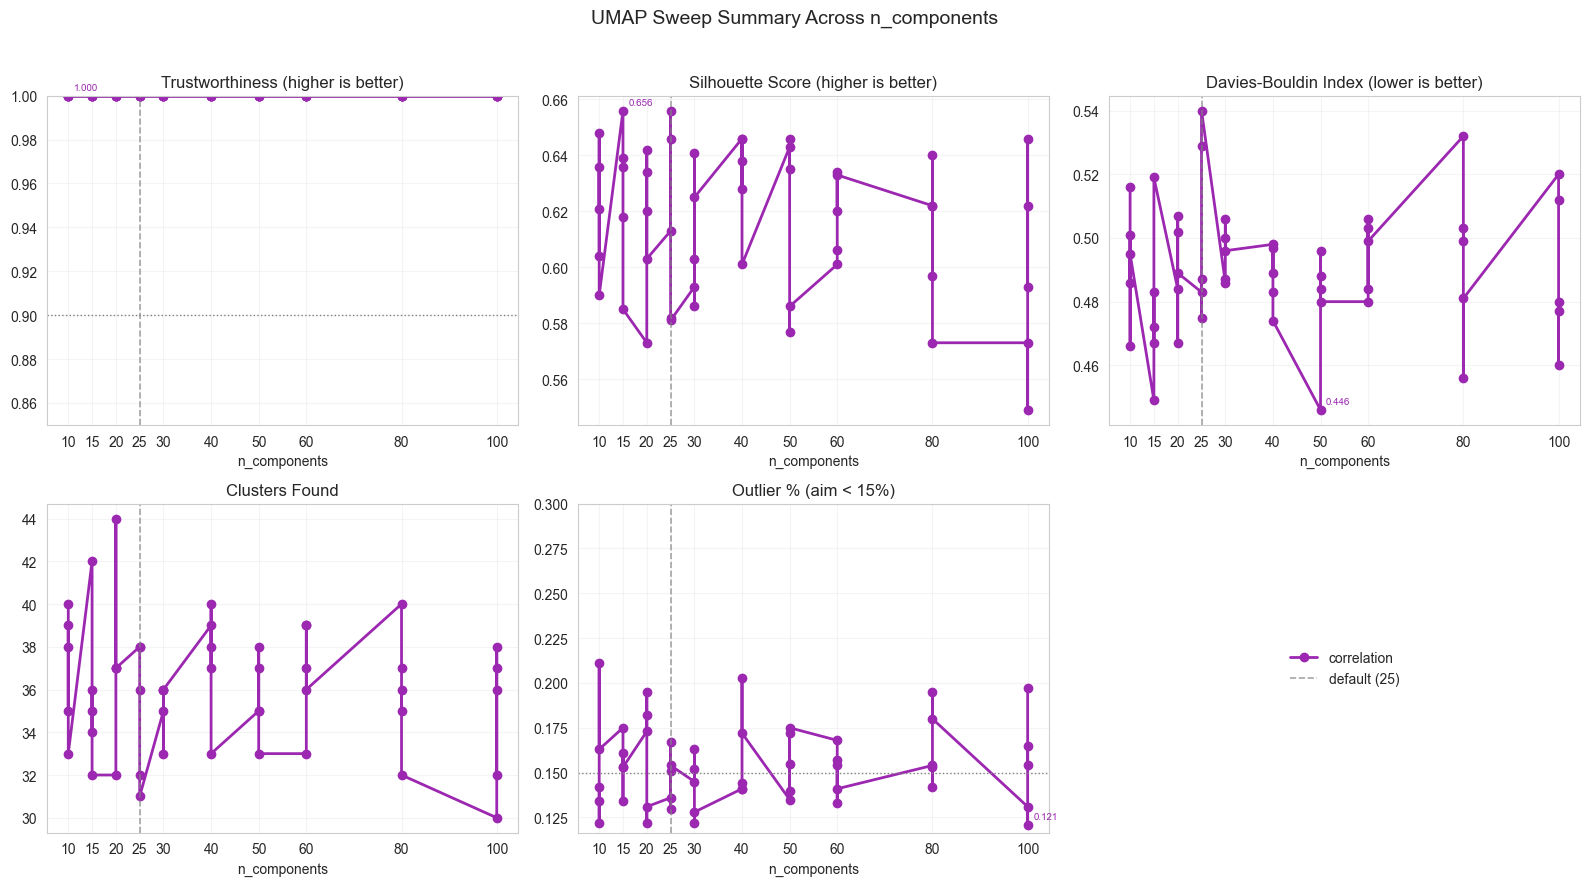

In [735]:
# Only runs if the sweep above was executed (RUN_UMAP_SWEEP = True)
try:
    sweep_df
except NameError:
    print("sweep_df not found — set RUN_UMAP_SWEEP = True in the cell above, then re-run.")
else:
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
    import numpy as np

    # Backward compatibility: older sweep output did not include a `metric` column.
    if 'metric' not in sweep_df.columns:
        inferred_metric = 'precomputed' if USE_ENSEMBLE_DISTANCE else 'correlation'
        sweep_df = sweep_df.copy()
        sweep_df['metric'] = inferred_metric
        print(f"Added missing 'metric' column to sweep_df (inferred: {inferred_metric}).")

    metrics = sweep_df['metric'].dropna().unique()
    n_comps = sorted(sweep_df['n_components'].unique())
    default_n = 25  # current default — dashed reference line

    # Colour palette: one colour per distance metric
    palette = {'euclidean': '#2196F3', 'cosine': '#FF9800', 'correlation': '#9C27B0', 'precomputed': '#4CAF50'}
    default_colours = ['#2196F3', '#FF9800', '#9C27B0', '#4CAF50']

    panels = [
        ('trustworthiness', 'Trustworthiness',     'higher is better', True,  0.85, 1.0),
        ('silhouette',      'Silhouette Score',     'higher is better', True,  None, None),
        ('davies_bouldin',  'Davies-Bouldin Index', 'lower is better',  False, None, None),
        ('n_clusters',      'Clusters Found',       '',                 None,  None, None),
        ('outlier_pct',     'Outlier %',            'aim < 15%',        False, None, 0.3),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()

    for ax_idx, (col, title, note, higher_better, ymin, ymax) in enumerate(panels):
        ax = axes[ax_idx]

        for idx, metric in enumerate(metrics):
            sub = sweep_df[sweep_df['metric'] == metric].sort_values('n_components')
            if sub.empty:
                continue
            colour = palette.get(metric, default_colours[idx % len(default_colours)])

            ax.plot(
                sub['n_components'], sub[col],
                marker='o', linewidth=2, markersize=6,
                label=metric, color=colour
            )

            # Annotate best value
            if higher_better is True:
                best_idx = sub[col].idxmax()
            elif higher_better is False:
                best_idx = sub[col].idxmin()
            else:
                best_idx = None

            if best_idx is not None:
                bx = sub.loc[best_idx, 'n_components']
                by = sub.loc[best_idx, col]
                ax.annotate(
                    f'{by:.3f}',
                    xy=(bx, by), xytext=(4, 4), textcoords='offset points',
                    fontsize=7, color=colour
                )

        # Reference line at default n_components
        ax.axvline(x=default_n, color='grey', linestyle='--', linewidth=1.2, alpha=0.7,
                   label=f'default ({default_n})')

        # Horizontal reference for trustworthiness (0.9 threshold)
        if col == 'trustworthiness':
            ax.axhline(y=0.9, color='grey', linestyle=':', linewidth=1)

        # Horizontal reference for outlier % (15%)
        if col == 'outlier_pct':
            ax.axhline(y=0.15, color='grey', linestyle=':', linewidth=1)

        ax.set_title(f'{title} ({note})' if note else title)
        ax.set_xlabel('n_components')
        ax.set_xticks(n_comps)
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
        if ymin is not None or ymax is not None:
            ax.set_ylim(ymin, ymax)
        ax.grid(alpha=0.2)

    # Legend + cleanup
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        axes[5].axis('off')
        axes[5].legend(handles, labels, loc='center', frameon=False)

    plt.suptitle('UMAP Sweep Summary Across n_components', fontsize=14, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


## 5a) Final UMAP after n_component Validation

In [737]:
import umap.umap_ as umap

if USE_ENSEMBLE_DISTANCE:
    # ── Precomputed distance matrix path ─────────────────────────────────────
    print('UMAP with precomputed ensemble distance matrix...')

    reducer_cluster = umap.UMAP(
        metric='precomputed',
        n_components=100,
        n_neighbors=30,        # Priority experiment: sweep [15, 30, 50, 100, 150]
        min_dist=0.0,
        random_state=42
    )

    reducer_3d = umap.UMAP(
        metric='precomputed',
        n_components=3,
        n_neighbors=30,
        min_dist=0.1,
        random_state=42
    )

    print('Fitting clustering embedding (60D, precomputed)...')
    embedding_cluster = reducer_cluster.fit_transform(ensemble_dist)

    print('Fitting 3D visualisation embedding...')
    embedding_3d = reducer_3d.fit_transform(ensemble_dist)

else:
    # ── Direct feature matrix path ───────────────────────────────────────────
    print('UMAP with correlation metric on weighted features...')

    reducer_cluster = umap.UMAP(
        n_components=100,        # Reduced from 80 — IDF weighting concentrates signal
        n_neighbors=30,         # Higher = more global structure preserved
        min_dist=0.0,           # Tightest packing — best for downstream clustering
        metric='correlation',   # Correlation metric — after IDF weighting, we care about
                                # profile shape rather than absolute magnitude
        random_state=42,
        low_memory=False
    )

    reducer_3d = umap.UMAP(
        n_components=3,
        n_neighbors=30,
        min_dist=0.1,           # Slightly looser for visual separation
        metric='correlation',   # Same metric as clustering for consistency
        random_state=42
    )

    print('Fitting clustering embedding (15D, correlation)...')
    embedding_cluster = reducer_cluster.fit_transform(X_weighted)

    print('Fitting 3D visualisation embedding...')
    embedding_3d = reducer_3d.fit_transform(X_weighted)

print(f'\n✓ Clustering embedding shape: {embedding_cluster.shape}')
print(f'✓ Visualisation embedding shape: {embedding_3d.shape}')

# Keep a 2D alias for any downstream cells that reference embedding_2d
embedding_2d = embedding_3d[:, :2]

UMAP with correlation metric on weighted features...
Fitting clustering embedding (15D, correlation)...
Fitting 3D visualisation embedding...
Fitting 3D visualisation embedding...

✓ Clustering embedding shape: (8000, 100)
✓ Visualisation embedding shape: (8000, 3)

✓ Clustering embedding shape: (8000, 100)
✓ Visualisation embedding shape: (8000, 3)


---
## Step 6: HDBSCAN Clustering

HDBSCAN is density-based — no need to pre-specify K. It finds the number of clusters
empirically and natively marks low-density movies as outliers (label `-1`).

**Why not K-Means?**
- K-Means assumes spherical, equally-sized clusters — movie clusters are neither
- K must be pre-specified — no principled way to choose it across 300+ features
- Hard assignments force boundary-straddling films into one bucket

**Why Euclidean in HDBSCAN?**
HDBSCAN operates on the already-transformed UMAP embedding. Euclidean distance
in that space reads density directly, which is exactly what HDBSCAN needs.



In [739]:
import hdbscan
from sklearn.metrics import silhouette_score, davies_bouldin_score
from itertools import product

# ── Parameter sweep — tune min_cluster_size, min_samples, and epsilon ────────
if RUN_HDBSCAN_SWEEP:
    import pandas as pd
    hdbscan_results = []

    min_cluster_sizes  = [5, 10, 15, 20, 30, 40, 60]
    min_samples_values = [1, 3, 5, 10, 15]
    epsilons           = [0.0, 0.1, 0.2, 0.3, 0.5]

    for mcs, ms, eps in product(min_cluster_sizes, min_samples_values, epsilons):
        c = hdbscan.HDBSCAN(
            min_cluster_size=mcs,
            min_samples=ms,
            cluster_selection_epsilon=eps,
            metric='euclidean',
            cluster_selection_method='eom'
        )
        lbls = c.fit_predict(embedding_cluster)
        n_c  = len(set(lbls)) - (1 if -1 in lbls else 0)
        n_o  = int(np.sum(lbls == -1))
        sil  = silhouette_score(embedding_cluster[lbls != -1], lbls[lbls != -1],
                                sample_size=2000, random_state=42) if n_c >= 2 else -1

        hdbscan_results.append({
            'min_cluster_size': mcs, 'min_samples': ms, 'epsilon': eps,
            'n_clusters': n_c, 'outlier_pct': round(n_o / len(lbls), 3),
            'silhouette': round(sil, 3)
        })

    hdbscan_df = pd.DataFrame(hdbscan_results)
    print(hdbscan_df.sort_values('silhouette', ascending=False).head(30).to_string(index=False))
    print('\n💡 Aim for outlier_pct < 0.20 and n_clusters in the 25-40 range.')
    print('   cluster_selection_epsilon is the most direct lever for outlier rate.')
    print('   Update the parameters below then re-run the final clusterer.')

# ── Final clustering ──────────────────────────────────────────────────────────
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,        # ~0.5% of 8000 movies — tune based on sweep
    min_samples=15,             # Controls outlier sensitivity
    cluster_selection_epsilon=0.2,  # Merges nearby clusters, absorbs borderline points
    metric='euclidean',         # Correct: operating on UMAP embedding
    cluster_selection_method='eom',  # Excess of Mass — better for uneven cluster sizes
    prediction_data=True        # Required for soft membership probabilities
)

cluster_labels = clusterer.fit_predict(embedding_cluster)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_outliers  = int(np.sum(cluster_labels == -1))

print(f'✓ HDBSCAN complete')
print(f'  Clusters found: {n_clusters}')
print(f'  Outliers:       {n_outliers} ({n_outliers/len(cluster_labels):.1%})')
print()
for k in sorted(set(cluster_labels)):
    label = f'Cluster {k}' if k != -1 else 'Outliers (-1)'
    print(f'  {label}: {(cluster_labels == k).sum():4d} movies')

 min_cluster_size  min_samples  epsilon  n_clusters  outlier_pct  silhouette
               40           15      0.1          37        0.154       0.651
               40           15      0.0          37        0.154       0.651
               40           15      0.2          35        0.143       0.647
               40           10      0.1          38        0.165       0.646
               40           10      0.0          38        0.165       0.646
               15           15      0.0          53        0.197       0.645
               15           15      0.1          53        0.197       0.645
               30           15      0.1          42        0.168       0.633
               30           15      0.0          42        0.168       0.633
               60           15      0.0          32        0.160       0.632
               60           15      0.1          32        0.160       0.632
               10           15      0.0          59        0.212       0.630

### Soft Cluster Probabilities & Secondary Rail Assignment

HDBSCAN provides membership probabilities — use these to flag movies near cluster
boundaries that could reasonably belong to more than one group.

Films near cluster boundaries get fractional membership across multiple rails,
enabling nuanced recommendation logic.

In [740]:
import hdbscan as hdbscan_module
import pandas as pd

soft_clusters = hdbscan_module.all_points_membership_vectors(clusterer)
# Shape: (n_movies, n_clusters)

# Primary rail assignment
primary_rail = np.argmax(soft_clusters, axis=1)

# Secondary rail — second highest membership above threshold
threshold = 0.15
secondary_rail = [
    sorted(range(len(row)), key=lambda i: row[i], reverse=True)[1]
    if sorted(row, reverse=True)[1] > threshold else -1
    for row in soft_clusters
]

results_df = pd.DataFrame({
    'tt_code':              tt_codes,
    'primary_cluster':      cluster_labels,
    'primary_probability':  clusterer.probabilities_,
    'secondary_cluster':    np.argsort(soft_clusters, axis=1)[:, -2],
    'secondary_probability': np.sort(soft_clusters, axis=1)[:, -2]
})

print(f'Results dataframe: {results_df.shape}')
print(f'\nConfidence distribution:')
assigned = results_df[results_df['primary_cluster'] != -1]
print(f'  High confidence (>0.8):       {(assigned["primary_probability"] > 0.8).sum():4d} movies')
print(f'  Medium confidence (0.4-0.8):  {((assigned["primary_probability"] >= 0.4) & (assigned["primary_probability"] <= 0.8)).sum():4d} movies')
print(f'  Low confidence (<0.4):        {(assigned["primary_probability"] < 0.4).sum():4d} movies')

# Secondary rail stats
has_secondary = sum(1 for r in secondary_rail if r != -1)
print(f'\n  Movies with secondary rail (>{threshold:.0%} membership): {has_secondary}')
display(results_df.head(10))

Results dataframe: (8000, 5)

Confidence distribution:
  High confidence (>0.8):       5652 movies
  Medium confidence (0.4-0.8):  1057 movies
  Low confidence (<0.4):         165 movies

  Movies with secondary rail (>15% membership): 11


,tt_code,primary_cluster,primary_probability,secondary_cluster,secondary_probability
0,tt0000679,-1,0.000000,16,2.773479e-02
1,tt0003740,14,1.000000,12,1.593140e-307
2,tt0005059,13,0.754764,12,9.061833e-02
3,tt0005078,-1,0.000000,30,8.730107e-02
4,tt0005808,41,1.000000,43,3.698867e-02
5,tt0006517,13,0.991770,12,9.568183e-02
6,tt0006736,0,0.990152,3,7.021198e-04
7,tt0006886,27,1.000000,20,2.375356e-307
8,tt0008735,31,0.921306,30,8.210408e-02
9,tt0008807,12,1.000000,13,4.828529e-307


### Recursive Sub-Clustering (Spotify Pattern)

Re-run UMAP + HDBSCAN on each individual cluster to discover sub-clusters
at finer resolution. This produces a **two-tier content hierarchy** — broad rails
and fine-grained sub-rails — with no additional data required.

In [741]:
sub_clusters = {}

print('Recursive sub-clustering...')
print(f'{"Cluster":<10s} {"Size":<8s} {"Sub-clusters":<15s} {"Sub-outliers"}')
print('-' * 55)

for cluster_id in range(n_clusters):
    cluster_mask = cluster_labels == cluster_id
    cluster_embedding = embedding_cluster[cluster_mask]

    if cluster_embedding.shape[0] < 30:
        print(f'{cluster_id:<10d} {cluster_embedding.shape[0]:<8d} {"skipped (too small)"}')
        continue  # too small to sub-cluster meaningfully

    sub_reducer = umap.UMAP(
        n_components=10,
        n_neighbors=15,
        min_dist=0.0,
        metric='euclidean',
        random_state=42
    )
    sub_embedding = sub_reducer.fit_transform(cluster_embedding)

    sub_clusterer = hdbscan.HDBSCAN(
        min_cluster_size=5,
        min_samples=3,
        metric='euclidean',
        prediction_data=True
    )
    sub_labels = sub_clusterer.fit_predict(sub_embedding)
    sub_clusters[cluster_id] = sub_labels

    n_sub = len(set(sub_labels)) - (1 if -1 in sub_labels else 0)
    n_sub_out = int(np.sum(sub_labels == -1))
    print(f'{cluster_id:<10d} {cluster_embedding.shape[0]:<8d} {n_sub:<15d} {n_sub_out}')

print(f'\n✓ Sub-clustered {len(sub_clusters)} / {n_clusters} clusters')

Recursive sub-clustering...
Cluster    Size     Sub-clusters    Sub-outliers
-------------------------------------------------------
0          85       2               0
1          68       2               0
2          200      8               4
2          200      8               4
3          516      35              27
4          28       skipped (too small)
5          122      9               8
3          516      35              27
4          28       skipped (too small)
5          122      9               8
6          127      9               5
7          129      4               0
6          127      9               5
7          129      4               0
8          759      50              52
9          60       3               0
8          759      50              52
9          60       3               0
10         389      25              20
11         33       2               0
12         25       skipped (too small)
13         185      8               6
10         389      

---
## Step 8: Outlier Handling (Three Tiers) + Sub-Cluster Integration

Rather than discarding outliers, classify them by HDBSCAN outlier score and handle
each tier appropriately:

1. **Tier 1 — Mild outliers**: assign to nearest cluster centroid
2. **Tier 2 — Moderate outliers**: flag as niche, assign loosely
3. **Tier 3 — True outliers**: genuinely uncategorisable, surface as "wild card" films

Sub-cluster labels are mapped back onto the full results dataframe so every movie
carries both its **primary rail** and its **sub-rail** (e.g. Cluster 3 → Sub 2).
Within-cluster outliers are also cross-referenced against sub-cluster outliers
to flag movies that are peripheral at *both* levels of the hierarchy.

In [742]:
from scipy.spatial.distance import cdist

# ── Compute centroids in both spaces ─────────────────────────────────────────
centroids_original = {}
centroids_umap     = {}

for cluster_id in range(n_clusters):
    mask = cluster_labels == cluster_id
    centroids_original[cluster_id] = X[mask].mean(axis=0)
    centroids_umap[cluster_id]     = embedding_cluster[mask].mean(axis=0)

centroid_df = pd.DataFrame(
    {cid: centroids_original[cid] for cid in range(n_clusters)},
    index=feature_names
).T

print(f'✓ Centroids computed in both spaces')
print(f'  Original space: {centroid_df.shape}  (n_clusters × n_features)')
print(f'  UMAP space:     ({len(centroids_umap)} centroids × {len(list(centroids_umap.values())[0])} dims)')

# ── Three-tier outlier classification ────────────────────────────────────────
outlier_scores = clusterer.outlier_scores_

tier1_mask = (cluster_labels == -1) & (outlier_scores < np.percentile(outlier_scores, 60))
tier2_mask = (cluster_labels == -1) & (~tier1_mask) & (outlier_scores < np.percentile(outlier_scores, 85))
tier3_mask = (cluster_labels == -1) & (outlier_scores >= np.percentile(outlier_scores, 85))

# Tier 1 — Mild outliers: assign to nearest cluster centroid
centroids_array = np.array([centroids_umap[i] for i in range(n_clusters)])

from sklearn.metrics import pairwise_distances_argmin
if tier1_mask.any():
    tier1_assignments = pairwise_distances_argmin(embedding_cluster[tier1_mask], centroids_array)
else:
    tier1_assignments = np.array([])

# ── Within-cluster distance outliers ─────────────────────────────────────────
def get_within_cluster_outliers(cluster_id, threshold_percentile=95):
    mask = cluster_labels == cluster_id
    cluster_embeddings = embedding_cluster[mask]
    centroid = centroids_umap[cluster_id]

    distances = cdist(
        cluster_embeddings,
        centroid.reshape(1, -1),
        metric='euclidean'
    ).flatten()

    threshold    = np.percentile(distances, threshold_percentile)
    outlier_mask = distances > threshold
    cluster_tts  = np.array(tt_codes)[mask]

    return pd.DataFrame({
        'tt_code':              cluster_tts[outlier_mask],
        'cluster':              cluster_id,
        'distance_to_centroid': distances[outlier_mask]
    })

# HDBSCAN native outliers
hdbscan_outliers = results_df[results_df['primary_cluster'] == -1]['tt_code'].tolist()

# Low-confidence border cases
low_confidence = results_df[
    (results_df['primary_cluster'] != -1) &
    (results_df['primary_probability'] < 0.4)
]

# Distance-based outliers within clusters
within_cluster_outliers = pd.concat([
    get_within_cluster_outliers(cid) for cid in range(n_clusters)
])

# ── Integrate sub-cluster labels into results_df ─────────────────────────────
sub_label_full = np.full(len(tt_codes), -1, dtype=int)

for cluster_id, sub_labels in sub_clusters.items():
    cluster_mask = cluster_labels == cluster_id
    sub_label_full[cluster_mask] = sub_labels

results_df['sub_cluster'] = sub_label_full

# Sub-cluster outliers: movies labelled -1 by the sub-clusterer
sub_cluster_outlier_mask = (results_df['primary_cluster'] != -1) & (results_df['sub_cluster'] == -1)
sub_cluster_outliers = results_df[sub_cluster_outlier_mask]

# Movies that are outliers at BOTH levels (within-cluster distant AND sub-cluster outlier)
within_outlier_tts = set(within_cluster_outliers['tt_code'].tolist())
sub_outlier_tts    = set(sub_cluster_outliers['tt_code'].tolist())
dual_level_outliers = within_outlier_tts & sub_outlier_tts

# Build a readable sub-cluster label for display: "Rail 3 → Sub 2"
results_df['rail_label'] = results_df.apply(
    lambda row: (
        f"Rail {row['primary_cluster']}"
        if row['primary_cluster'] == -1
        else (
            f"Rail {row['primary_cluster']} → Sub {row['sub_cluster']}"
            if row['sub_cluster'] != -1
            else f"Rail {row['primary_cluster']} → Sub-outlier"
        )
    ), axis=1
)

# ── Summary ──────────────────────────────────────────────────────────────────
print(f'\nOutlier Summary:')
print(f'  --- Three-Tier Classification (top-level) ---')
print(f'  Tier 1 — Mild (reassigned to nearest):   {int(tier1_mask.sum()):4d} movies')
print(f'  Tier 2 — Moderate (niche):                {int(tier2_mask.sum()):4d} movies')
print(f'  Tier 3 — True outliers (wild card):       {int(tier3_mask.sum()):4d} movies')
print(f'\n  --- Additional Categories ---')
print(f'  HDBSCAN native outliers:                  {len(hdbscan_outliers):4d} movies')
print(f'  Low confidence (<0.4):                    {len(low_confidence):4d} movies')
print(f'  Within-cluster distant (top 5%):          {len(within_cluster_outliers):4d} movies')
print(f'\n  --- Sub-Cluster Integration ---')
print(f'  Movies with sub-cluster assignment:       {int((sub_label_full >= 0).sum()):4d}')
print(f'  Sub-cluster outliers (label -1 at sub):   {len(sub_cluster_outliers):4d} movies')
print(f'  Dual-level outliers (distant + sub -1):   {len(dual_level_outliers):4d} movies')

print(f'\n  Sub-cluster distribution per rail:')
for cid in sorted(sub_clusters.keys()):
    slabs = sub_clusters[cid]
    n_sub = len(set(slabs)) - (1 if -1 in slabs else 0)
    n_out = int(np.sum(slabs == -1))
    print(f'    Rail {cid:2d}: {n_sub:2d} sub-rails, {n_out:3d} sub-outliers')

✓ Centroids computed in both spaces
  Original space: (44, 269)  (n_clusters × n_features)
  UMAP space:     (44 centroids × 100 dims)

Outlier Summary:
  --- Three-Tier Classification (top-level) ---
  Tier 1 — Mild (reassigned to nearest):    924 movies
  Tier 2 — Moderate (niche):                 198 movies
  Tier 3 — True outliers (wild card):          4 movies

  --- Additional Categories ---
  HDBSCAN native outliers:                  1126 movies
  Low confidence (<0.4):                     165 movies
  Within-cluster distant (top 5%):           359 movies

  --- Sub-Cluster Integration ---
  Movies with sub-cluster assignment:       6433
  Sub-cluster outliers (label -1 at sub):    441 movies
  Dual-level outliers (distant + sub -1):     18 movies

  Sub-cluster distribution per rail:
    Rail  0:  2 sub-rails,   0 sub-outliers
    Rail  1:  2 sub-rails,   0 sub-outliers
    Rail  2:  8 sub-rails,   4 sub-outliers
    Rail  3: 35 sub-rails,  27 sub-outliers
    Rail  5:  9 sub-r

---
## Step 9: 3D Visualisation (with Sub-Clusters & Outlier Tiers)

Plot the 3D UMAP embedding coloured by HDBSCAN cluster. Hover shows:
- Primary rail + sub-rail assignment (e.g. "Rail 3 → Sub 2")
- Confidence and secondary cluster
- Outlier tier classification (for outlier points)

Outlier tiers are colour-coded: Tier 1 (yellow), Tier 2 (orange), Tier 3 (red).
Sub-cluster outliers within assigned clusters are shown with diamond markers.

In [743]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# ── Build the plot dataframe ─────────────────────────────────────────────────
plot_df = pd.DataFrame({
    'x':                   embedding_3d[:, 0],
    'y':                   embedding_3d[:, 1],
    'z':                   embedding_3d[:, 2],
    'tt_code':             tt_codes,
    'cluster':             cluster_labels,
    'probability':         results_df['primary_probability'].values,
    'secondary_cluster':   results_df['secondary_cluster'].values,
    'secondary_prob':      results_df['secondary_probability'].values,
    'sub_cluster':         results_df['sub_cluster'].values,
    'rail_label':          results_df['rail_label'].values,
})

# Add cluster name
plot_df['cluster_name'] = plot_df['cluster'].apply(
    lambda c: cluster_names.get(c, {}).get('name', f'Cluster {c}') if c != -1 else 'Outlier'
)

# Add movie title — try OMDB first, then genre_data movie_name, then tt_code
genre_title_map = dict(zip(genres['movie_id'], genres['movie_name']))

def get_title(tt):
    if 'omdb_data' in dir() and omdb_data and tt in omdb_data:
        title = omdb_data[tt].get('Title')
        if title:
            return title
    if tt in genre_title_map:
        return genre_title_map[tt]
    return tt

plot_df['title'] = plot_df['tt_code'].apply(get_title)

# Confidence tier label
def conf_tier(p):
    if p >= 0.8:  return 'High (>=80%)'
    if p >= 0.4:  return 'Medium (40-80%)'
    return 'Low (<40%)'
plot_df['conf_tier'] = plot_df['probability'].apply(conf_tier)

# Mark outlier tiers and sub-cluster outliers
plot_df['outlier_tier'] = 'none'
plot_df.loc[tier1_mask, 'outlier_tier'] = 'Tier 1 (mild)'
plot_df.loc[tier2_mask, 'outlier_tier'] = 'Tier 2 (moderate)'
plot_df.loc[tier3_mask, 'outlier_tier'] = 'Tier 3 (true outlier)'

# Flag sub-cluster outliers (assigned to a rail but sub_cluster == -1)
plot_df['is_sub_outlier'] = (plot_df['cluster'] != -1) & (plot_df['sub_cluster'] == -1)

# Flag dual-level outliers
plot_df['is_dual_outlier'] = plot_df['tt_code'].isin(dual_level_outliers)

# ── Colour palette (base RGB values) ────────────────────────────────────────
PLOTLY_RGB = [
    (31,119,180), (255,127,14), (44,160,44), (214,39,40), (148,103,189),
    (140,86,75), (227,119,194), (127,127,127), (188,189,34), (23,190,207),
    (174,199,232), (255,187,120), (152,223,138), (255,152,150), (197,176,213),
    (196,156,148), (247,182,210), (199,199,199), (219,219,141), (158,218,229),
]

def rgba_list(base_rgb, probabilities):
    r, g, b = base_rgb
    return [f'rgba({r},{g},{b},{max(0.2, min(1.0, p))})' for p in probabilities]

# ── Build 3D figure ──────────────────────────────────────────────────────────
fig = go.Figure()

# ── Outlier tiers (colour-coded by severity) ─────────────────────────────────
tier_configs = [
    (tier1_mask, 'Tier 1 — Mild',     'rgba(255,235,59,0.5)',  3, 'circle'),
    (tier2_mask, 'Tier 2 — Moderate',  'rgba(255,152,0,0.6)',   3, 'circle'),
    (tier3_mask, 'Tier 3 — True',      'rgba(244,67,54,0.7)',   4, 'diamond'),
]

# Non-tiered outliers (those that don't fall into tier masks — shouldn't happen, but safety)
any_tier = tier1_mask | tier2_mask | tier3_mask
untiered_outlier = (plot_df['cluster'] == -1) & ~any_tier

for tier_mask_arr, tier_name, tier_colour, tier_size, tier_symbol in tier_configs:
    if not tier_mask_arr.any():
        continue
    od = plot_df[tier_mask_arr]
    fig.add_trace(go.Scatter3d(
        x=od['x'], y=od['y'], z=od['z'],
        mode='markers',
        name=f'{tier_name} ({tier_mask_arr.sum()})',
        marker=dict(color=tier_colour, size=tier_size, symbol=tier_symbol),
        customdata=np.stack([
            od['tt_code'], od['title'],
            od['probability'].round(3).astype(str),
            od['secondary_cluster'].astype(str),
            od['secondary_prob'].round(3).astype(str),
            od['outlier_tier']
        ], axis=1),
        hovertemplate=(
            '<b>%{customdata[1]}</b><br>'
            '%{customdata[0]}<br>'
            '<i>%{customdata[5]}</i><br>'
            'Confidence: %{customdata[2]}<br>'
            'Nearest: Cluster %{customdata[3]} (%{customdata[4]})<br>'
            '<extra></extra>'
        ),
        legendrank=9990 + [t[1] for t in tier_configs].index(tier_name)
    ))

if untiered_outlier.any():
    od = plot_df[untiered_outlier]
    fig.add_trace(go.Scatter3d(
        x=od['x'], y=od['y'], z=od['z'],
        mode='markers',
        name=f'Outliers — unclassified ({untiered_outlier.sum()})',
        marker=dict(color='rgba(200,200,200,0.3)', size=2),
        hovertemplate='<b>Outlier</b><extra></extra>',
        legendrank=9999
    ))

# ── One trace per cluster (sub-cluster info in hover) ────────────────────────
for cluster_id in sorted(set(cluster_labels)):
    if cluster_id == -1:
        continue
    mask   = plot_df['cluster'] == cluster_id
    cd     = plot_df[mask]
    rgb    = PLOTLY_RGB[cluster_id % len(PLOTLY_RGB)]
    cname  = cluster_names.get(cluster_id, {}).get('name', f'Cluster {cluster_id}')

    # Separate sub-cluster outliers (diamond) from normal points (circle)
    sub_out_mask = cd['is_sub_outlier']
    normal_mask  = ~sub_out_mask

    # Normal points
    if normal_mask.any():
        cd_n = cd[normal_mask]
        colours = rgba_list(rgb, cd_n['probability'].values)

        fig.add_trace(go.Scatter3d(
            x=cd_n['x'], y=cd_n['y'], z=cd_n['z'],
            mode='markers',
            name=f'[{cluster_id}] {cname} (n={mask.sum()})',
            marker=dict(color=colours, size=3, symbol='circle',
                        line=dict(width=0.3, color='white')),
            customdata=np.stack([
                cd_n['tt_code'], cd_n['title'],
                (cd_n['probability'] * 100).round(1).astype(str),
                cd_n['secondary_cluster'].astype(str),
                (cd_n['secondary_prob'] * 100).round(1).astype(str),
                cd_n['conf_tier'],
                cd_n['rail_label']
            ], axis=1),
            hovertemplate=(
                '<b>%{customdata[1]}</b><br>'
                '%{customdata[0]}<br>'
                '%{customdata[6]}<br>'
                f'{cname}<br>'
                'Confidence: %{customdata[2]}%  (%{customdata[5]})<br>'
                'Secondary: Cluster %{customdata[3]} (%{customdata[4]}%)<br>'
                '<extra></extra>'
            ),
            legendrank=cluster_id
        ))

    # Sub-cluster outliers (diamond marker, same colour but hollow feel)
    if sub_out_mask.any():
        cd_s = cd[sub_out_mask]
        r, g, b = rgb
        sub_out_colour = f'rgba({r},{g},{b},0.4)'

        fig.add_trace(go.Scatter3d(
            x=cd_s['x'], y=cd_s['y'], z=cd_s['z'],
            mode='markers',
            name=f'[{cluster_id}] sub-outliers ({sub_out_mask.sum()})',
            marker=dict(color=sub_out_colour, size=3, symbol='diamond',
                        line=dict(width=0.5, color=f'rgb({r},{g},{b})')),
            customdata=np.stack([
                cd_s['tt_code'], cd_s['title'],
                (cd_s['probability'] * 100).round(1).astype(str),
                cd_s['secondary_cluster'].astype(str),
                (cd_s['secondary_prob'] * 100).round(1).astype(str),
                cd_s['conf_tier'],
                cd_s['rail_label']
            ], axis=1),
            hovertemplate=(
                '<b>%{customdata[1]}</b><br>'
                '%{customdata[0]}<br>'
                '%{customdata[6]} (sub-outlier)<br>'
                f'{cname}<br>'
                'Confidence: %{customdata[2]}%  (%{customdata[5]})<br>'
                'Secondary: Cluster %{customdata[3]} (%{customdata[4]}%)<br>'
                '<extra></extra>'
            ),
            legendrank=cluster_id + 500,
            showlegend=True,
            visible='legendonly'  # hidden by default — click legend to show
        ))

# ── Layout ───────────────────────────────────────────────────────────────────
total_sub = sum(len(set(s)) - (1 if -1 in s else 0) for s in sub_clusters.values())
fig.update_layout(
    title=dict(
        text=(f'<b>3D UMAP + HDBSCAN — {n_clusters} rails, {total_sub} sub-rails, '
              f'{n_outliers} outliers (3 tiers)</b><br>'
              f'<sup>Drag to rotate | Scroll to zoom | Hover for rail + sub-rail | '
              f'Diamonds = sub-outliers (click legend to show)</sup>'),
        font=dict(size=14)
    ),
    scene=dict(
        xaxis_title='UMAP 1',
        yaxis_title='UMAP 2',
        zaxis_title='UMAP 3',
        xaxis=dict(showgrid=True, gridcolor='#e0e0e0', backgroundcolor='#f8f8f8'),
        yaxis=dict(showgrid=True, gridcolor='#e0e0e0', backgroundcolor='#f8f8f8'),
        zaxis=dict(showgrid=True, gridcolor='#e0e0e0', backgroundcolor='#f8f8f8'),
    ),
    legend=dict(
        title='Clusters & Outlier Tiers',
        font=dict(size=10),
        itemsizing='constant',
        tracegroupgap=2,
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='#cccccc', borderwidth=1
    ),
    hovermode='closest',
    width=1100, height=800,
    margin=dict(l=0, r=200, t=80, b=0),
    paper_bgcolor='white',
)

fig.show()
print(f'\n✓ 3D interactive plot rendered')
print(f'  Circles  = normal cluster members (alpha = confidence)')
print(f'  Diamonds = sub-cluster outliers (hidden by default — click legend to reveal)')
print(f'  Yellow/Orange/Red = outlier tiers 1/2/3')
print(f'  Hover shows: Rail → Sub-rail assignment, confidence, secondary cluster')


✓ 3D interactive plot rendered
  Circles  = normal cluster members (alpha = confidence)
  Diamonds = sub-cluster outliers (hidden by default — click legend to reveal)
  Yellow/Orange/Red = outlier tiers 1/2/3
  Hover shows: Rail → Sub-rail assignment, confidence, secondary cluster


### Cluster Review

Set `REVIEW_CLUSTER_ID` to any cluster number to inspect its movies,
top discriminative features, and confidence breakdown.

Useful for sanity-checking whether each cluster's assigned name
actually reflects the movies inside it.


In [744]:
# ── Set the cluster you want to inspect ─────────────────────────────────────
REVIEW_CLUSTER_ID = 0   # <-- change this

# ── Pull movies in that cluster ──────────────────────────────────────────────
mask        = cluster_labels == REVIEW_CLUSTER_ID
cluster_tts = np.array(tt_codes)[mask]
cluster_probs = results_df[results_df['primary_cluster'] == REVIEW_CLUSTER_ID]['primary_probability'].values
cname       = cluster_names.get(REVIEW_CLUSTER_ID, {}).get('name', f'Cluster {REVIEW_CLUSTER_ID}')
cdesc       = cluster_names.get(REVIEW_CLUSTER_ID, {}).get('description', '—')

print(f'{"="*70}')
print(f'CLUSTER {REVIEW_CLUSTER_ID}: {cname}')
print(f'{"="*70}')
print(f'Description : {cdesc}')
print(f'Size        : {mask.sum()} movies')
print(f'Avg confidence: {cluster_probs.mean():.1%}')
print(f'  High (≥80%): {(cluster_probs >= 0.8).sum():4d} movies')
print(f'  Med  (40-80%): {((cluster_probs >= 0.4) & (cluster_probs < 0.8)).sum():4d} movies')
print(f'  Low  (<40%):  {(cluster_probs < 0.4).sum():4d} movies')

# Top discriminative features
top_pos, top_neg = get_discriminative_features(REVIEW_CLUSTER_ID, top_n=10)
print(f'\nTop features ABOVE average:')
for feat, delta in top_pos.items():
    bar = '█' * int(delta * 30)
    print(f'  {feat:<45s} +{delta:.3f}  {bar}')
print(f'\nTop features BELOW average:')
for feat, delta in top_neg.items():
    bar = '█' * int(abs(delta) * 30)
    print(f'  {feat:<45s} {delta:.3f}  {bar}')

# Movie list — with titles from OMDB if available
print(f'\n{"─"*70}')
print(f'MOVIES IN CLUSTER {REVIEW_CLUSTER_ID}  (sorted by confidence, descending)')
print(f'{"─"*70}')

genre_title_map = dict(zip(genres['movie_id'], genres['movie_name']))

movie_rows = []
for tt, prob in zip(cluster_tts, cluster_probs):
    # Title: OMDB > genre_data > tt_code
    if 'omdb_data' in dir() and omdb_data and tt in omdb_data:
        title  = omdb_data[tt].get('Title', genre_title_map.get(tt, tt))
        year   = omdb_data[tt].get('Year',  '—')
        rating = omdb_data[tt].get('imdbRating', '—')
        genre  = omdb_data[tt].get('Genre', '—')
    else:
        title  = genre_title_map.get(tt, tt)
        year   = '—'
        rating = '—'
        genre  = '—'
    movie_rows.append({'tt_code': tt, 'title': title, 'year': year,
                       'imdb_rating': rating, 'genre': genre, 'confidence': prob})

review_df = pd.DataFrame(movie_rows).sort_values('confidence', ascending=False)

# Display top 30 and tail 10 to spot weakest assignments
print(f'\n--- Top 30 most confident assignments ---')
display(review_df.head(30))
print(f'\n--- 10 least confident assignments (most likely to be wrong cluster) ---')
display(review_df.tail(10))
print(f'\n💡 Low-confidence movies (bottom rows) are candidates for manual reassignment.')
print(f'   Run this cell again with a different REVIEW_CLUSTER_ID to compare clusters.')


CLUSTER 0: The American Frontier Odyssey
Description : These films share a common narrative thread of rugged individualism and pursuit of justice on the vast, untamed American frontier.
Size        : 85 movies
Avg confidence: 66.2%
  High (≥80%):   31 movies
  Med  (40-80%):   37 movies
  Low  (<40%):    17 movies

Top features ABOVE average:
  genre_Western                                 +0.977  █████████████████████████████
  Rural Story                                   +0.333  █████████
  Heavy Gunplay                                 +0.320  █████████
  The Pre-Modern Era                            +0.254  ███████
  Set in America                                +0.248  ███████
  Natural splendor                              +0.144  ████
  Pursuit of Justice                            +0.143  ████
  A village story                               +0.140  ████
  A quest for retribution                       +0.132  ███
  Brave Protagonist                             +0.125  ███

Top f

,tt_code,title,year,imdb_rating,genre,confidence
75,tt13845956,Righteous Blood,2021,3.9,"Action, Western",1.000000
81,tt3255590,El Camino Christmas,2017,5.7,"Comedy, Crime, Western",1.000000
58,tt0098412,Sundown: The Vampire in Retreat,—,—,—,1.000000
52,tt0068675,Hannie Caulder,1971,6.4,"Crime, Drama, Western",1.000000
49,tt0067714,The Scavengers,—,—,—,1.000000
46,tt0066612,Compañeros,1970,7.2,"Action, Comedy, Western",1.000000
6,tt0024500,Riders of Destiny,—,—,—,1.000000
43,tt0065051,Support Your Local Sheriff!,—,—,—,1.000000
1,tt0009900,Back to God's Country,—,—,—,1.000000
73,tt1235536,Lucky Luke,—,—,—,1.000000



--- 10 least confident assignments (most likely to be wrong cluster) ---


,tt_code,title,year,imdb_rating,genre,confidence
50,tt0067770,Red Sun,1971,6.8,"Action, Drama, Western",0.336903
61,tt0162496,Nobleza gaucha,1915,6.3,"Drama, History, Western",0.333904
68,tt11170782,Dilly Loves Kitty,—,—,—,0.333690
40,tt0062479,The Way West,—,—,—,0.325946
53,tt0068979,Creeping Death,—,—,—,0.322310
19,tt0044460,The Bushwhackers,1951,5.6,"Film-Noir, Western",0.318727
42,tt0064300,The 5-Man Army,1969,6.5,"Action, Adventure, Drama",0.317421
35,tt0060558,Jesse James Meets Frankenstein's Daughter,1966,3.4,"Horror, Sci-Fi, Western",0.308763
10,tt0034384,Western Union,1941,6.7,"History, Western",0.282908
79,tt2404435,The Magnificent Seven,2016,6.9,"Action, Adventure, Drama",0.217231



💡 Low-confidence movies (bottom rows) are candidates for manual reassignment.
   Run this cell again with a different REVIEW_CLUSTER_ID to compare clusters.


---
## Step 10: Name Clusters & Sub-Clusters via Ollama

The naming prompt uses **discriminative features** — the delta between each cluster's
centroid and the global mean. Features elevated above average define what makes
each cluster distinct; suppressed features define what it avoids.

Sub-clusters are named the same way, but the delta is computed against the
**parent cluster centroid** rather than the global mean — this surfaces what
makes each sub-rail unique *within* its parent rail.

In [745]:
import requests
import json as json_module

def get_discriminative_features(cluster_id, top_n=20):
    global_mean  = centroid_df.mean(axis=0)
    delta        = centroid_df.loc[cluster_id] - global_mean
    top_positive = delta.nlargest(top_n)
    top_negative = delta.nsmallest(top_n)
    return top_positive, top_negative

def get_sub_discriminative_features(parent_cluster_id, sub_cluster_id, top_n=15):
    """Compute discriminative features for a sub-cluster relative to its parent."""
    parent_mask = cluster_labels == parent_cluster_id
    sub_labels  = sub_clusters[parent_cluster_id]
    sub_mask_within = sub_labels == sub_cluster_id

    # Get the movie indices for this sub-cluster
    parent_indices = np.where(parent_mask)[0]
    sub_indices    = parent_indices[sub_mask_within]

    # Centroid of the sub-cluster in original feature space
    sub_centroid    = X[sub_indices].mean(axis=0)
    parent_centroid = X[parent_mask].mean(axis=0)

    # Delta: what makes this sub-cluster different from its parent
    delta = pd.Series(sub_centroid - parent_centroid, index=feature_names)
    top_positive = delta.nlargest(top_n)
    top_negative = delta.nsmallest(top_n)
    return top_positive, top_negative

def query_ollama(prompt, model=None):
    model = model or OLLAMA_MODEL
    try:
        response = requests.post(
            'http://localhost:11434/api/generate',
            json={
                'model': model,
                'prompt': prompt,
                'stream': False,
                'options': {'temperature': 0.3}
            },
            timeout=180
        )
        data = response.json()
        if 'error' in data:
            raise RuntimeError(f"Ollama error: {data['error']}")
        return data['response'].strip()
    except Exception as e:
        print(f'  ⚠ Ollama call failed: {e}')
        return f'{{"name": "Unnamed", "description": "LLM unavailable: {e}"}}'

def name_cluster(cluster_id, sample_tt_codes=None, title_lookup=None):
    top_pos, top_neg = get_discriminative_features(cluster_id)

    pos_str = '\n'.join([f'  - {f}: +{v:.3f} above average' for f, v in top_pos.items()])
    neg_str = '\n'.join([f'  - {f}: {v:.3f} below average'  for f, v in top_neg.items()])

    sample_str = ''
    if sample_tt_codes and title_lookup:
        titles     = [title_lookup.get(tt, tt) for tt in sample_tt_codes[:6]]
        sample_str = f'\nExample movies: {", ".join(titles)}'

    prompt = f"""You are a film taxonomy expert. A cluster of movies has been grouped by
the similarity of their content profile relative to their own averages — meaning these
movies share the same pattern of which elements are prominent and which are understated.

FEATURES ELEVATED ABOVE AVERAGE IN THIS CLUSTER:
{pos_str}

FEATURES SUPPRESSED BELOW AVERAGE IN THIS CLUSTER:
{neg_str}
{sample_str}

Based on this profile, give this cluster a precise, evocative name (3-6 words)
and a one-sentence description of what unifies these films.

Respond in JSON only:
{{"name": "cluster name", "description": "one sentence"}}"""

    raw = query_ollama(prompt)
    try:
        return json_module.loads(raw)
    except json_module.JSONDecodeError:
        return {'name': f'Cluster {cluster_id}', 'description': raw}

def name_sub_cluster(parent_cluster_id, sub_cluster_id, parent_name,
                     sample_tt_codes=None, title_lookup=None):
    """Name a sub-cluster using its delta from the parent cluster centroid."""
    top_pos, top_neg = get_sub_discriminative_features(parent_cluster_id, sub_cluster_id)

    pos_str = '\n'.join([f'  - {f}: +{v:.3f} above parent avg' for f, v in top_pos.items()])
    neg_str = '\n'.join([f'  - {f}: {v:.3f} below parent avg'  for f, v in top_neg.items()])

    sample_str = ''
    if sample_tt_codes and title_lookup:
        titles     = [title_lookup.get(tt, tt) for tt in sample_tt_codes[:6]]
        sample_str = f'\nExample movies: {", ".join(titles)}'

    prompt = f"""You are a film taxonomy expert. This is a SUB-CLUSTER within the larger
rail called "{parent_name}". These movies share the parent rail's broad profile but
differ from the parent average in specific ways.

FEATURES ELEVATED ABOVE THE PARENT RAIL AVERAGE:
{pos_str}

FEATURES SUPPRESSED BELOW THE PARENT RAIL AVERAGE:
{neg_str}
{sample_str}

Give this sub-cluster a precise, evocative name (2-5 words) that describes what
distinguishes it FROM the parent rail "{parent_name}". Also give a one-sentence
description of what makes this sub-group unique within the parent.

Respond in JSON only:
{{"name": "sub-cluster name", "description": "one sentence"}}"""

    raw = query_ollama(prompt)
    try:
        return json_module.loads(raw)
    except json_module.JSONDecodeError:
        return {'name': f'Sub {sub_cluster_id}', 'description': raw}

print('✓ Naming functions defined (clusters + sub-clusters)')
print('  Cluster names:     delta from global mean')
print('  Sub-cluster names: delta from parent cluster centroid')

✓ Naming functions defined (clusters + sub-clusters)
  Cluster names:     delta from global mean
  Sub-cluster names: delta from parent cluster centroid


In [746]:
# Requires Ollama running locally: ollama serve
# Run: ollama pull llama3.1:8b   (or whichever model is set in OLLAMA_MODEL above)

title_lookup = {}  # Replace with actual lookup if available
cluster_names = {}
sub_cluster_names = {}  # {(parent_id, sub_id): {'name': ..., 'description': ...}}

# ── Name top-level clusters ──────────────────────────────────────────────────
print(f'Naming {n_clusters} clusters via Ollama...\n')
print(f'{"Rail":<6s} {"Size":<7s} {"Avg Conf":<10s} {"Name"}')
print('=' * 70)

for cluster_id in range(n_clusters):
    mask       = cluster_labels == cluster_id
    sample_tts = np.array(tt_codes)[mask][:6].tolist()
    result     = name_cluster(cluster_id, sample_tts, title_lookup)
    cluster_names[cluster_id] = result

    avg_conf = results_df[results_df['primary_cluster'] == cluster_id]['primary_probability'].mean()
    print(f'{cluster_id:<6d} {mask.sum():<7d} {avg_conf:<10.1%} {result["name"]}')
    print(f'       {result["description"]}')

# ── Name sub-clusters ────────────────────────────────────────────────────────
print(f'\n\n{"="*70}')
print(f'Naming sub-clusters via Ollama...')
print(f'{"="*70}\n')

for parent_id in sorted(sub_clusters.keys()):
    sub_labels = sub_clusters[parent_id]
    unique_subs = sorted(set(sub_labels))
    unique_subs = [s for s in unique_subs if s != -1]  # skip sub-outliers

    if not unique_subs:
        continue

    parent_name = cluster_names.get(parent_id, {}).get('name', f'Cluster {parent_id}')
    parent_mask = cluster_labels == parent_id
    parent_indices = np.where(parent_mask)[0]

    print(f'Rail {parent_id}: {parent_name} ({len(unique_subs)} sub-rails)')
    print(f'  {"Sub":<5s} {"Size":<7s} {"Avg Conf":<10s} {"Name"}')
    print(f'  {"-"*60}')

    for sub_id in unique_subs:
        sub_mask_within = sub_labels == sub_id
        sub_indices = parent_indices[sub_mask_within]
        sub_size = len(sub_indices)

        # Get sample tt_codes for this sub-cluster
        sub_tts = np.array(tt_codes)[sub_indices][:6].tolist()

        # Compute average confidence for movies in this sub-cluster
        sub_tt_set = set(np.array(tt_codes)[sub_indices])
        sub_rows = results_df[results_df['tt_code'].isin(sub_tt_set)]
        avg_sub_conf = sub_rows['primary_probability'].mean()

        result = name_sub_cluster(parent_id, sub_id, parent_name, sub_tts, title_lookup)
        sub_cluster_names[(parent_id, sub_id)] = result

        print(f'  {sub_id:<5d} {sub_size:<7d} {avg_sub_conf:<10.1%} {result["name"]}')
        print(f'        {result["description"]}')

    # Also report sub-outlier count
    n_sub_out = int(np.sum(sub_labels == -1))
    if n_sub_out > 0:
        sub_out_indices = parent_indices[sub_labels == -1]
        sub_out_tt_set = set(np.array(tt_codes)[sub_out_indices])
        sub_out_rows = results_df[results_df['tt_code'].isin(sub_out_tt_set)]
        avg_out_conf = sub_out_rows['primary_probability'].mean()
        print(f'  {"out":<5s} {n_sub_out:<7d} {avg_out_conf:<10.1%} (sub-outliers — not named)')
    print()

print(f'\n✓ Named {len(cluster_names)} rails and {len(sub_cluster_names)} sub-rails')

Naming 44 clusters via Ollama...

Rail   Size    Avg Conf   Name
0      85      66.2%      The American Frontier Odyssey
       These films share a common narrative thread of rugged individualism and pursuit of justice on the open range.
0      85      66.2%      The American Frontier Odyssey
       These films share a common narrative thread of rugged individualism and pursuit of justice on the open range.
1      68      67.4%      Crime Thrillers of Deception
       These films masterfully weave psychological suspense and crime elements to create a complex web of deception.
1      68      67.4%      Crime Thrillers of Deception
       These films masterfully weave psychological suspense and crime elements to create a complex web of deception.
2      200     96.3%      Indian Action Dramas
       These films share a common blend of action, drama, and cultural elements set against the backdrop of modern India.
2      200     96.3%      Indian Action Dramas
       These films share a co

---
## Step 11: Final Assembly


In [747]:
# ── Map cluster + sub-cluster names onto results_df ──────────────────────────
results_df['cluster_name'] = results_df['primary_cluster'].map(
    {cid: d['name'] for cid, d in cluster_names.items()}
)
results_df['cluster_description'] = results_df['primary_cluster'].map(
    {cid: d['description'] for cid, d in cluster_names.items()}
)

# Map sub-cluster names
def get_sub_name(row):
    key = (row['primary_cluster'], row['sub_cluster'])
    if key in sub_cluster_names:
        return sub_cluster_names[key]['name']
    elif row['sub_cluster'] == -1 and row['primary_cluster'] != -1:
        return '(sub-outlier)'
    return None

results_df['sub_cluster_name'] = results_df.apply(get_sub_name, axis=1)

# Update rail_label to use actual names
def build_named_rail_label(row):
    if row['primary_cluster'] == -1:
        return 'Outlier'
    cname = cluster_names.get(row['primary_cluster'], {}).get('name', f"Rail {row['primary_cluster']}")
    if row['sub_cluster'] != -1:
        sname = sub_cluster_names.get((row['primary_cluster'], row['sub_cluster']), {}).get('name', f"Sub {row['sub_cluster']}")
        return f'{cname} → {sname}'
    else:
        return f'{cname} → (sub-outlier)'

results_df['rail_label'] = results_df.apply(build_named_rail_label, axis=1)

results_df['umap_x'] = embedding_2d[:, 0]
results_df['umap_y'] = embedding_2d[:, 1]

results_df.to_csv('movie_clusters_final.csv', index=False)
print(f'✓ Saved movie_clusters_final.csv ({len(results_df):,} rows)')

# ── Cluster summary (top-level) ─────────────────────────────────────────────
cluster_summary = pd.DataFrame([{
    'cluster_id':      cid,
    'name':            cluster_names[cid]['name'],
    'description':     cluster_names[cid]['description'],
    'movie_count':     int((cluster_labels == cid).sum()),
    'avg_confidence':  round(results_df[results_df['primary_cluster'] == cid]['primary_probability'].mean(), 3),
    'n_sub_rails':     len(set(sub_clusters.get(cid, []))) - (1 if -1 in sub_clusters.get(cid, []) else 0)
} for cid in range(n_clusters)]).sort_values('movie_count', ascending=False)

cluster_summary.to_csv('cluster_summary.csv', index=False)
print(f'✓ Saved cluster_summary.csv')

# ── Sub-cluster summary ──────────────────────────────────────────────────────
sub_summary_rows = []
for (pid, sid), meta in sub_cluster_names.items():
    parent_mask = cluster_labels == pid
    parent_indices = np.where(parent_mask)[0]
    sub_mask = sub_clusters[pid] == sid
    sub_indices = parent_indices[sub_mask]
    sub_tt_set = set(np.array(tt_codes)[sub_indices])
    sub_rows = results_df[results_df['tt_code'].isin(sub_tt_set)]

    sub_summary_rows.append({
        'parent_cluster': pid,
        'parent_name':    cluster_names[pid]['name'],
        'sub_cluster':    sid,
        'sub_name':       meta['name'],
        'sub_description': meta['description'],
        'movie_count':    len(sub_indices),
        'avg_confidence': round(sub_rows['primary_probability'].mean(), 3)
    })

sub_summary_df = pd.DataFrame(sub_summary_rows).sort_values(['parent_cluster', 'sub_cluster'])
sub_summary_df.to_csv('sub_cluster_summary.csv', index=False)
print(f'✓ Saved sub_cluster_summary.csv ({len(sub_summary_df)} sub-rails)')

print(f'\n{"="*80}')
print('TOP-LEVEL RAILS')
print(f'{"="*80}')
print(cluster_summary.to_string(index=False))

print(f'\n{"="*80}')
print('SUB-RAILS')
print(f'{"="*80}')
print(sub_summary_df.to_string(index=False))

✓ Saved movie_clusters_final.csv (8,000 rows)
✓ Saved cluster_summary.csv
✓ Saved sub_cluster_summary.csv (380 sub-rails)

TOP-LEVEL RAILS
 cluster_id                                  name                                                                                                                                       description  movie_count  avg_confidence  n_sub_rails
          8             Cyberpunk Odyssey Cluster                                          These films unite as futuristic, high-tech thrillers exploring the intersection of science and humanity.          759           0.988           50
         14      The Biographical Odyssey Cluster                                             These films share a common narrative thread, exploring the lives and struggles of historical figures.          536           0.981           33
          3      East Asian Action Cinema Cluster                                                                       Characterized by intense, s

### Deliverable 1: List of Groups with Appropriate Names

**Method**: LLM-generated names based on top weighted features and sample movies.

In [748]:
print('=' * 100)
print('DELIVERABLE 1: MOVIE RAILS WITH NAMES (Two-Tier Hierarchy)')
print('=' * 100)

for cid in range(n_clusters):
    meta = cluster_names[cid]
    size = int((cluster_labels == cid).sum())
    avg_conf = results_df[results_df['primary_cluster'] == cid]['primary_probability'].mean()
    top_pos, _ = get_discriminative_features(cid, top_n=5)

    print(f"\n🎬 Rail {cid}: {meta['name']}  (confidence: {avg_conf:.1%})")
    print(f"   Size: {size} movies")
    print(f"   Top Features: {', '.join(top_pos.index[:5].tolist())}")

    # Show sub-rails for this cluster
    if cid in sub_clusters:
        sub_labels = sub_clusters[cid]
        unique_subs = sorted(set(sub_labels))
        unique_subs = [s for s in unique_subs if s != -1]

        parent_mask = cluster_labels == cid
        parent_indices = np.where(parent_mask)[0]

        if unique_subs:
            for sid in unique_subs:
                sub_meta = sub_cluster_names.get((cid, sid), {'name': f'Sub {sid}'})
                sub_mask = sub_labels == sid
                sub_indices = parent_indices[sub_mask]
                sub_size = len(sub_indices)

                sub_tt_set = set(np.array(tt_codes)[sub_indices])
                sub_rows = results_df[results_df['tt_code'].isin(sub_tt_set)]
                avg_sub_conf = sub_rows['primary_probability'].mean()

                print(f"     ├── Sub {sid}: {sub_meta['name']}  ({sub_size} movies, confidence: {avg_sub_conf:.1%})")

            # Sub-outliers
            n_sub_out = int(np.sum(sub_labels == -1))
            if n_sub_out > 0:
                print(f"     └── (sub-outliers): {n_sub_out} movies")

DELIVERABLE 1: MOVIE RAILS WITH NAMES (Two-Tier Hierarchy)

🎬 Rail 0: The American Frontier Odyssey  (confidence: 66.2%)
   Size: 85 movies
   Top Features: genre_Western, Rural Story, Heavy Gunplay, The Pre-Modern Era, Set in America
     ├── Sub 0: Western Quests and Legends  (25 movies, confidence: 61.7%)
     ├── Sub 1: Romantic Trailblazers  (60 movies, confidence: 68.1%)

🎬 Rail 1: Crime Thrillers of Deception  (confidence: 67.4%)
   Size: 68 movies
   Top Features: genre_Film-Noir, A Black & White, genre_Crime, Psychological Suspense, A Crime Thriller
     ├── Sub 0: Deception-Driven Pursuit  (41 movies, confidence: 72.9%)
     ├── Sub 1: California Family Deceit  (27 movies, confidence: 59.0%)

🎬 Rail 2: Indian Action Dramas  (confidence: 96.3%)
   Size: 200 movies
   Top Features: Set in India, An Asian-Driven Story, Focus on Asian Culture, genre_Action, Pursuit of Justice
     ├── Sub 0: Romantic Indian Dramas  (78 movies, confidence: 94.9%)
     ├── Sub 1: Crime-Driven India

### Deliverable 2: One Paragraph Descriptions

In [749]:
print('=' * 100)
print('DELIVERABLE 2: RAIL DESCRIPTIONS')
print('=' * 100)

for cid in range(n_clusters):
    meta = cluster_names[cid]
    print(f"\n🎬 {meta['name']}")
    print(f"   {meta['description']}")

DELIVERABLE 2: RAIL DESCRIPTIONS

🎬 The American Frontier Odyssey
   These films share a common narrative thread of rugged individualism and pursuit of justice on the open range.

🎬 Crime Thrillers of Deception
   These films masterfully weave psychological suspense and crime elements to create a complex web of deception.

🎬 Indian Action Dramas
   These films share a common blend of action, drama, and cultural elements set against the backdrop of modern India.

🎬 East Asian Action Cinema Cluster
   Characterized by intense, stylized action and exploration of Asian culture.

🎬 Triumph Over Adversity Stories
   These films celebrate underdog victories and overcoming challenges, often with inspirational biographical narratives.

🎬 The Underdog's Triumph
   Films celebrating the triumph of the underdog over adversity and personal growth.

🎬 Romantic Melodrama Cluster
   Character-driven stories emphasizing emotional depth and musical elements.

🎬 Musical Romances and Comedies
   These fil

### Deliverable 3: Explanation of Cohesion

**Method**: Discriminative feature analysis from HDBSCAN density-based clustering.

Each cluster is cohesive because HDBSCAN identified density-connected regions
in the UMAP embedding where films share elevated or suppressed features relative
to the global mean.

In [750]:
print('=' * 100)
print('DELIVERABLE 3: COHESION EXPLANATIONS')
print('=' * 100)

for cid in range(n_clusters):
    meta = cluster_names[cid]
    top_pos, top_neg = get_discriminative_features(cid, top_n=5)
    size = int((cluster_labels == cid).sum())
    avg_conf = results_df[results_df['primary_cluster'] == cid]['primary_probability'].mean()

    print(f"\n🎬 {meta['name']} ({size} movies, avg confidence: {avg_conf:.1%})")
    print(f"   This cluster is cohesive because HDBSCAN found a density-connected")
    print(f"   region in the 60D UMAP embedding where these films share elevated:")
    for feat, delta in top_pos.items():
        print(f"     +{delta:.3f}  {feat}")
    print(f"   And suppressed:")
    for feat, delta in top_neg.items():
        print(f"     {delta:.3f}  {feat}")
    print(f"\n   All {size} movies in this cluster share this distinctive content profile.")

DELIVERABLE 3: COHESION EXPLANATIONS

🎬 The American Frontier Odyssey (85 movies, avg confidence: 66.2%)
   This cluster is cohesive because HDBSCAN found a density-connected
   region in the 60D UMAP embedding where these films share elevated:
     +0.977  genre_Western
     +0.333  Rural Story
     +0.320  Heavy Gunplay
     +0.254  The Pre-Modern Era
     +0.248  Set in America
   And suppressed:
     -0.245  A Late 20th and Early 21st Century Narrative
     -0.204  genre_Comedy
     -0.185  genre_Crime
     -0.152  Set in Europe
     -0.132  Uneasy Characters

   All 85 movies in this cluster share this distinctive content profile.

🎬 Crime Thrillers of Deception (68 movies, avg confidence: 67.4%)
   This cluster is cohesive because HDBSCAN found a density-connected
   region in the 60D UMAP embedding where these films share elevated:
     +0.977  genre_Film-Noir
     +0.814  A Black & White
     +0.521  genre_Crime
     +0.401  Psychological Suspense
     +0.391  A Crime Thriller


### Deliverable 4: Flaws and Caveats

In [751]:
print('=' * 100)
print('DELIVERABLE 4: FLAWS AND CAVEATS')
print('=' * 100)

print(f"""
Pipeline Configuration Used:
  USE_ENSEMBLE_DISTANCE : {USE_ENSEMBLE_DISTANCE}
  ENABLE_PHASE2_AUDIO   : {ENABLE_PHASE2_AUDIO}
  APPLY_IDF_WEIGHTING   : {APPLY_IDF_WEIGHTING}

### Density-Based Clustering (HDBSCAN)
- Outlier rate ({n_outliers/len(cluster_labels):.1%}) is irreducible with sparse data.
  Three-tier handling mitigates but does not eliminate this.
- Soft membership probabilities allow multi-rail assignment, but primary
  cluster is still a hard boundary for reporting.

### Ensemble Distance (Step 3½)
- When enabled, the weight ratio (continuous/genre/audio) is a hyperparameter
  that needs empirical tuning. Default 75/25 is a starting point.
- The precomputed distance matrix is O(n²) in memory — may be prohibitive
  for corpora >> 10,000 films.

### Feature Dependency
- Quality depends entirely on the 269-feature genome taxonomy.
- If features are Western-centric, international films may cluster poorly.
- Missing nuance for anime, Bollywood, or niche genres.

### Phase 2 Audio (when enabled)
- Trailer audio may not represent the full film (trailers are marketing cuts).
- Coverage gaps (<80%) degrade ensemble quality.

### Cold Start Problem
- New movies require complete feature extraction before assignment.
- HDBSCAN approximate_predict() can assign new points without refitting.

### LLM Naming
- Cluster names depend on Ollama model quality and prompt engineering.
- Different models may produce different names for the same cluster.
""")

DELIVERABLE 4: FLAWS AND CAVEATS

Pipeline Configuration Used:
  USE_ENSEMBLE_DISTANCE : False
  ENABLE_PHASE2_AUDIO   : False
  APPLY_IDF_WEIGHTING   : True

### Density-Based Clustering (HDBSCAN)
- Outlier rate (14.1%) is irreducible with sparse data.
  Three-tier handling mitigates but does not eliminate this.
- Soft membership probabilities allow multi-rail assignment, but primary
  cluster is still a hard boundary for reporting.

### Ensemble Distance (Step 3½)
- When enabled, the weight ratio (continuous/genre/audio) is a hyperparameter
  that needs empirical tuning. Default 75/25 is a starting point.
- The precomputed distance matrix is O(n²) in memory — may be prohibitive
  for corpora >> 10,000 films.

### Feature Dependency
- Quality depends entirely on the 269-feature genome taxonomy.
- If features are Western-centric, international films may cluster poorly.
- Missing nuance for anime, Bollywood, or niche genres.

### Phase 2 Audio (when enabled)
- Trailer audio may not repr

### Deliverable 5: Evaluation vs. Genre Grouping

In [752]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import calinski_harabasz_score

print('=' * 100)
print('DELIVERABLE 5: EVALUATION VS. GENRE BASELINE')
print('=' * 100)

# Genre-only baseline
genre_cols = [col for col in feature_matrix.columns if col.startswith('genre_')]
X_genre_only = feature_matrix[genre_cols].to_numpy()

scaler_genre = StandardScaler()
X_genre_scaled = scaler_genre.fit_transform(X_genre_only)

print(f'Running K-Means on genre-only features (K={n_clusters})...')
kmeans_genre = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
genre_labels = kmeans_genre.fit_predict(X_genre_scaled)

genre_sil = silhouette_score(X_genre_scaled, genre_labels)
genre_db  = davies_bouldin_score(X_genre_scaled, genre_labels)
genre_ch  = calinski_harabasz_score(X_genre_scaled, genre_labels)

# Our pipeline metrics (on non-outlier movies)
valid = cluster_labels != -1
our_sil = silhouette_score(embedding_cluster[valid], cluster_labels[valid],
                           sample_size=2000, random_state=42)
our_db  = davies_bouldin_score(embedding_cluster[valid], cluster_labels[valid])
our_ch  = calinski_harabasz_score(embedding_cluster[valid], cluster_labels[valid])

print('\n' + '=' * 100)
print('COMPARISON: GENRE BASELINE VS. GENOME PIPELINE')
print('=' * 100)

comparison_df = pd.DataFrame([
    {
        'Method': 'Genre-Only K-Means',
        'Features': f'{len(genre_cols)} genres',
        'Silhouette': round(genre_sil, 3),
        'Davies-Bouldin': round(genre_db, 3),
        'Calinski-Harabasz': round(genre_ch, 1)
    },
    {
        'Method': 'Genome Pipeline (UMAP+HDBSCAN)',
        'Features': f'{X.shape[1]} features' + (' + audio' if ENABLE_PHASE2_AUDIO else ''),
        'Silhouette': round(our_sil, 3),
        'Davies-Bouldin': round(our_db, 3),
        'Calinski-Harabasz': round(our_ch, 1)
    }
])

print('\n' + comparison_df.to_string(index=False))

sil_improvement = ((our_sil - genre_sil) / abs(genre_sil)) * 100
db_improvement  = ((genre_db - our_db) / genre_db) * 100
ch_improvement  = ((our_ch - genre_ch) / genre_ch) * 100

print(f'\n{"="*100}')
print('IMPROVEMENTS OVER GENRE BASELINE')
print(f'{"="*100}')
print(f'Silhouette Score:      {sil_improvement:+.1f}% ({"better" if sil_improvement > 0 else "worse"})')
print(f'Davies-Bouldin Index:  {db_improvement:+.1f}% ({"better" if db_improvement > 0 else "worse"})')
print(f'Calinski-Harabasz:     {ch_improvement:+.1f}% ({"better" if ch_improvement > 0 else "worse"})')

print(f'\nPipeline: ensemble={USE_ENSEMBLE_DISTANCE}, audio={ENABLE_PHASE2_AUDIO}, idf={APPLY_IDF_WEIGHTING}')

DELIVERABLE 5: EVALUATION VS. GENRE BASELINE
Running K-Means on genre-only features (K=44)...

COMPARISON: GENRE BASELINE VS. GENOME PIPELINE

                        Method     Features  Silhouette  Davies-Bouldin  Calinski-Harabasz
            Genre-Only K-Means    22 genres       0.503           0.949             1088.8
Genome Pipeline (UMAP+HDBSCAN) 269 features       0.583           0.490            14979.5

IMPROVEMENTS OVER GENRE BASELINE
Silhouette Score:      +15.8% (better)
Davies-Bouldin Index:  +48.4% (better)
Calinski-Harabasz:     +1275.8% (better)

Pipeline: ensemble=False, audio=False, idf=True

COMPARISON: GENRE BASELINE VS. GENOME PIPELINE

                        Method     Features  Silhouette  Davies-Bouldin  Calinski-Harabasz
            Genre-Only K-Means    22 genres       0.503           0.949             1088.8
Genome Pipeline (UMAP+HDBSCAN) 269 features       0.583           0.490            14979.5

IMPROVEMENTS OVER GENRE BASELINE
Silhouette Score:      +15

### Step 12: Save Pipeline Artifacts for Dashboard\n\nSave all in-memory pipeline objects to `results/pipeline_artifacts.pkl` so the Streamlit dashboard can load them without re-running the notebook.

In [753]:
import joblib
from pathlib import Path
from datetime import datetime

results_dir = Path('results')
results_dir.mkdir(exist_ok=True)

artifacts = {
    # Embeddings
    'embedding_cluster': embedding_cluster,
    'embedding_3d': embedding_3d,
    'embedding_2d': embedding_2d,
    
    # Cluster results
    'cluster_labels': cluster_labels,
    'probabilities': clusterer.probabilities_,
    'soft_clusters': soft_clusters,
    'outlier_scores': outlier_scores,
    'n_clusters': n_clusters,
    
    # Centroids
    'centroids_original': centroids_original,
    'centroids_umap': centroids_umap,
    
    # Sub-clusters
    'sub_clusters': sub_clusters,
    
    # Feature data
    'X': X,
    'X_weighted': X_weighted,
    'continuous_data': continuous_data,
    'binary_data': binary_data,
    'feature_names': list(feature_names),
    'tt_codes': list(tt_codes),
    'continuous_cols': list(continuous_cols),
    'binary_cols': list(binary_cols),
    
    # Names
    'cluster_names': cluster_names,
    'sub_cluster_names': sub_cluster_names,
    
    # Tier masks
    'tier1_mask': tier1_mask,
    'tier2_mask': tier2_mask,
    'tier3_mask': tier3_mask,
    
    # Pipeline config
    'config': {
        'USE_ENSEMBLE_DISTANCE': USE_ENSEMBLE_DISTANCE,
        'APPLY_IDF_WEIGHTING': APPLY_IDF_WEIGHTING,
        'ENABLE_PHASE2_AUDIO': ENABLE_PHASE2_AUDIO,
        'WEIGHT_CONTINUOUS': WEIGHT_CONTINUOUS,
        'WEIGHT_GENRE': WEIGHT_GENRE,
        'n_components': 60,
        'n_neighbors': 30 if not USE_ENSEMBLE_DISTANCE else 50,
        'min_dist': 0.0,
        'metric': 'precomputed' if USE_ENSEMBLE_DISTANCE else 'correlation',
        'min_cluster_size': 40,
        'min_samples': 10,
        'cluster_selection_epsilon': 0.0,
        'timestamp': datetime.now().isoformat(),
    },
    
    # IDF weights
    'idf_weights': idf_weights if APPLY_IDF_WEIGHTING else None,
    'variance_weights': variance_weights if APPLY_IDF_WEIGHTING else None,
    'combined_weights': combined_weights if APPLY_IDF_WEIGHTING else None,
}

joblib.dump(artifacts, results_dir / 'pipeline_artifacts.pkl', compress=3)

print(f'Pipeline artifacts saved to results/pipeline_artifacts.pkl')
print(f'Keys: {list(artifacts.keys())}')
print(f'Config: {artifacts["config"]}')

Pipeline artifacts saved to results/pipeline_artifacts.pkl
Keys: ['embedding_cluster', 'embedding_3d', 'embedding_2d', 'cluster_labels', 'probabilities', 'soft_clusters', 'outlier_scores', 'n_clusters', 'centroids_original', 'centroids_umap', 'sub_clusters', 'X', 'X_weighted', 'continuous_data', 'binary_data', 'feature_names', 'tt_codes', 'continuous_cols', 'binary_cols', 'cluster_names', 'sub_cluster_names', 'tier1_mask', 'tier2_mask', 'tier3_mask', 'config', 'idf_weights', 'variance_weights', 'combined_weights']
Config: {'USE_ENSEMBLE_DISTANCE': False, 'APPLY_IDF_WEIGHTING': True, 'ENABLE_PHASE2_AUDIO': False, 'WEIGHT_CONTINUOUS': 0.9, 'WEIGHT_GENRE': 0.1, 'n_components': 60, 'n_neighbors': 30, 'min_dist': 0.0, 'metric': 'correlation', 'min_cluster_size': 40, 'min_samples': 10, 'cluster_selection_epsilon': 0.0, 'timestamp': '2026-02-23T03:22:04.351782'}


### Launch the Dashboard

Run the Streamlit dashboard to explore pipeline results interactively. See  for a full guide to each page.

In [ ]:
# Launch the Streamlit dashboard (runs in a separate process)
# Uncomment the line below to launch from the notebook:
!streamlit run app.py

print("To launch the dashboard, run from your terminal:")
print("  cd " + str(Path(".").resolve()) + " && streamlit run app.py")
print("  streamlit run app.py")
print("Or uncomment the line above to launch directly from the notebook.")


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8503
  Network URL: http://192.168.1.134:8503

  For better performance, install the Watchdog module:

  $ xcode-select --install
  $ pip install watchdog
            
2026-02-23 11:46:58.095 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-02-23 11:46:58.095 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.


---
## 🎯 Project HOLLYWOOD: Complete

### Summary

Pipeline implemented with all 8 steps from the Genome Clustering update:

✅ **Split Feature Views** — continuous taxonomy vs binary genre
✅ **IDF + Variance Weighting** — combined weight on continuous features
✅ **Ensemble Distance Matrix** — optional test (`USE_ENSEMBLE_DISTANCE`)
✅ **UMAP** — precomputed or correlation, with n_neighbors sweep
✅ **HDBSCAN** — with epsilon parameter and full grid search
✅ **Recursive Sub-Clustering** — Spotify-pattern two-tier hierarchy
✅ **Soft Membership** — primary + secondary rail with threshold
✅ **Three-Tier Outlier Handling** — mild/moderate/true outlier classification
✅ **Phase 2 Audio** — optional toggle (`ENABLE_PHASE2_AUDIO`), coverage-gated
✅ **LLM Cluster Naming** — via Ollama discriminative features

### Configuration Toggles

| Toggle | Default | Effect |
|---|---|---|
| `USE_ENSEMBLE_DISTANCE` | `False` | Step 3½: separate correlation + jaccard distance matrices |
| `ENABLE_PHASE2_AUDIO` | `False` | Phase 2: audio features as third distance view |
| `APPLY_IDF_WEIGHTING` | `True` | IDF × √variance weighting on continuous features |
| `RUN_UMAP_SWEEP` | `False` | n_components × n_neighbors grid search |
| `RUN_HDBSCAN_SWEEP` | `False` | min_cluster_size × min_samples × epsilon grid search |

### Next Steps

1. Sweep `n_neighbors` [15, 30, 50, 100, 150] with `RUN_UMAP_SWEEP = True`
2. Sweep HDBSCAN epsilon with `RUN_HDBSCAN_SWEEP = True`
3. Test ensemble distance with `USE_ENSEMBLE_DISTANCE = True`
4. When audio coverage reaches 80%, enable `ENABLE_PHASE2_AUDIO = True`